# scAlphaGenome Decoder

## Experimental Goal

We want to show that our model is **better than AlphaGenome at adapting to predict cell-type specific expression from scRNA-seq data**. The key claims:

1. **Coverage advantage**: AlphaGenome natively supports a fixed, limited set of cell types (ENCODE CL ontology terms). Our model — by conditioning on scVI latent embeddings — can generalise to *any* cell type with scRNA-seq coverage.
2. **Quality advantage**: For the cell types that AlphaGenome *does* support (available in `agcell`), our cross-attention model trained with scVI conditioning should outperform a naive MLP baseline that directly uses AlphaGenome's cell-type-conditioned output tracks.

### Architecture
- **scAlphaGenomeDecoder** (main): UBERON-conditioned AG sequence tracks [B, 8192] + scVI cell-type embeddings [B, n_ct, 50] → cross-attention → expression [B, n_ct]
- **AGCellBaseline** (comparison): cell-type-specific AG tracks from `agcell` [B, n_ct, 8192] → MLP → expression [B, n_ct]

All data is loaded from **Google Drive root**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
GDRIVE_ROOT = '/content/drive/MyDrive'
print(f'Drive root: {GDRIVE_ROOT}')

Mounted at /content/drive
Drive root: /content/drive/MyDrive


In [34]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Hyperparameters ────────────────────────────────────────────────────────────
ORGANS       = ['heart', 'lung', 'kidney', 'liver']
ASSAY        = '10X'
D_MODEL      = 128
N_HEADS      = 8
N_LAYERS     = 3
SCVI_DIM     = 50
HYPER_HIDDEN = 256
AG_BINS      = 8192
GENE_BATCH   = 256
LR           = 1e-4
N_EPOCHS     = 20
TRAIN_FRAC   = 0.8
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [83]:
def load_organ(gdrive_root, organ, assay):
    """Load and align AG-UBERON features with scVI embeddings for one organ.

    Returns a dict with:
      - features: [n_genes, 8192] (float32)
      - labels:   [n_shared_ct, n_genes] raw log-CPM (float32)
      - labels_z: [n_shared_ct, n_genes] z-scored across CTs (float32)
      - gene_mean, gene_std: [1, n_genes] used to z-score (float32)
      - scvi:    [n_shared_ct, scvi_dim] (float32)
      - gene_ids, cell_type_ids, ct_names
    """
    ag_path   = os.path.join(gdrive_root, f'{organ}_{assay}_uberon_ag.npz')
    scvi_path = os.path.join(gdrive_root, f'{organ}_{assay}_cell_type_embeds.parquet')

    ag         = np.load(ag_path, allow_pickle=True)
    ag_feat    = ag['features'].astype(np.float32)   # [n_genes, 8192]
    ag_labels  = ag['labels'].astype(np.float32)     # [n_ct, n_genes]  log-CPM
    gene_ids   = ag['gene_ids']
    ag_ct_ids  = ag['cell_type_ids']

    scvi_df   = pd.read_parquet(scvi_path)
    scvi_cols = [c for c in scvi_df.columns if c.startswith('scvi_')]
    scvi_mat  = scvi_df[scvi_cols].values.astype(np.float32)  # [n_ct_scvi, scvi_dim]
    scvi_ids  = np.array(scvi_df.index.tolist())

    # Align cell types present in BOTH datasets
    ag_ct_map   = {ct: i for i, ct in enumerate(ag_ct_ids)}
    scvi_ct_map = {ct: i for i, ct in enumerate(scvi_ids)}
    shared = [ct for ct in ag_ct_ids if ct in scvi_ct_map]

    ag_idx   = np.array([ag_ct_map[ct]   for ct in shared])
    scvi_idx = np.array([scvi_ct_map[ct] for ct in shared])

    print(f'  {organ}: {ag_feat.shape[0]:,} genes | '
          f'{len(shared)}/{len(ag_ct_ids)} cell types aligned '
          f'(scVI has {len(scvi_ids)} total)')

    # Raw labels aligned to shared CTs: shape [n_shared_ct, n_genes]
    labels_raw = ag_labels[ag_idx]

    # Per-gene standardization (z-score across cell types). This focuses the
    # learning on cross-CT variation rather than per-gene mean offsets.
    gene_mean = labels_raw.mean(axis=0, keepdims=True)   # [1, n_genes]
    gene_std  = labels_raw.std(axis=0, keepdims=True)    # [1, n_genes]
    # Avoid division by (near) zero: clamp small stds to 1.0 (no scaling)
    gene_std_clamped = np.where(gene_std < 1e-6, 1.0, gene_std)
    labels_z = (labels_raw - gene_mean) / gene_std_clamped

    return {
        'features'      : ag_feat,                     # [n_genes, 8192]
        'labels'        : labels_raw.astype(np.float32),                  # [n_shared_ct, n_genes] (raw log-CPM)
        'labels_z'      : labels_z.astype(np.float32), # [n_shared_ct, n_genes] (z-scored)
        'gene_mean'     : gene_mean.astype(np.float32),
        'gene_std'      : gene_std_clamped.astype(np.float32),
        'scvi'          : scvi_mat[scvi_idx].astype(np.float32),           # [n_shared_ct, 50]
        'gene_ids'      : gene_ids,
        'cell_type_ids' : np.array(shared),
        'ct_names'      : scvi_df.loc[shared, 'cell_ontology_class'].values
                          if 'cell_ontology_class' in scvi_df.columns else shared,
    }

In [36]:
print('Loading organ data from Google Drive...')
organ_data = {}
for organ in ORGANS:
    try:
        organ_data[organ] = load_organ(GDRIVE_ROOT, organ, ASSAY)
    except FileNotFoundError as e:
        print(f'  [warn] Missing file for {organ}: {e}')

ORGAN_LIST = sorted(organ_data.keys())
ORGAN_IDX  = {o: i for i, o in enumerate(ORGAN_LIST)}
N_ORGANS   = len(ORGAN_LIST)
print(f'\nLoaded {N_ORGANS} organs: {ORGAN_LIST}')

Loading organ data from Google Drive...
  heart: 50,000 genes | 15/15 cell types aligned (scVI has 15 total)
  heart: 50,000 genes | 15/15 cell types aligned (scVI has 15 total)
  lung: 50,000 genes | 29/29 cell types aligned (scVI has 29 total)
  lung: 50,000 genes | 29/29 cell types aligned (scVI has 29 total)
  kidney: 50,000 genes | 10/10 cell types aligned (scVI has 10 total)
  kidney: 50,000 genes | 10/10 cell types aligned (scVI has 10 total)
  liver: 50,000 genes | 22/22 cell types aligned (scVI has 22 total)

Loaded 4 organs: ['heart', 'kidney', 'liver', 'lung']
  liver: 50,000 genes | 22/22 cell types aligned (scVI has 22 total)

Loaded 4 organs: ['heart', 'kidney', 'liver', 'lung']


In [84]:
# ── Gene train / val splits (80 / 20, fixed seed) ─────────────────────────────
gene_splits = {}
for organ, data in organ_data.items():
    n = data['features'].shape[0]
    rng = np.random.RandomState(SEED)
    idx = rng.permutation(n)
    n_train = int(n * TRAIN_FRAC)
    gene_splits[organ] = {'train': idx[:n_train], 'val': idx[n_train:]}
    print(f'{organ}: {n_train:,} train / {n - n_train:,} val genes')

heart: 40,000 train / 10,000 val genes
lung: 40,000 train / 10,000 val genes
kidney: 40,000 train / 10,000 val genes
liver: 40,000 train / 10,000 val genes


In [ ]:
class OrganGeneDataset(Dataset):
    """One sample = one gene; returns the AG track and all-CT raw log-CPM labels.

    NOTE: This dataset now returns z-scored labels (labels_z) for training the main
    model. The raw labels are kept in organ_data for denormalization at eval time.
    """
    def __init__(self, ag_features, labels_z, gene_indices):
        self.ag     = ag_features  # [n_genes, 8192]  numpy
        self.labels = labels_z     # [n_ct, n_genes]  numpy (z-scored across CTs)
        self.idx    = gene_indices

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        g = self.idx[i]
        return (
            torch.from_numpy(self.ag[g]),           # [8192]
            torch.from_numpy(self.labels[:, g]),    # [n_ct]
        )


class AGCellDataset(Dataset):
    """One sample = one gene; returns all-CT cell-conditioned AG tracks and raw log-CPM labels.

    This dataset optionally supports a `mask` array of shape [n_ct, n_genes] indicating which
    (cell type, gene) pairs are valid (True) and which are missing (False). When a mask is
    provided, __getitem__ returns (ag_cell[:, g, :], labels[:, g], mask[:, g]). Training
    and evaluation use the mask to compute losses only over valid entries.
    """
    def __init__(self, ag_cell_features, labels, gene_indices, mask=None):
        self.ag_cell = ag_cell_features  # [n_ct, n_genes, 8192]  numpy
        self.labels  = labels            # [n_ct, n_genes]  numpy, raw log-CPM
        self.idx     = gene_indices
        self.mask    = mask              # None or numpy array [n_ct, n_genes] of bool/int

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        g = self.idx[i]
        ag = torch.from_numpy(self.ag_cell[:, g, :])   # [n_ct, 8192]
        lb = torch.from_numpy(self.labels[:, g])       # [n_ct]
        if self.mask is None:
            return ag, lb
        else:
            m = torch.from_numpy(self.mask[:, g].astype(np.uint8))  # [n_ct]
            return ag, lb, m

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Model 1: scAlphaGenomeDecoder
# #   Q = scVI cell-type embeddings (expanded by hypernetwork)
# #   K/V = UBERON-AG sequence tokens
# # ─────────────────────────────────────────────────────────────────────────────

# class AGTokenizer(nn.Module):
#     """Two-layer CNN: 8192 bins → 128 tokens of dim d_model."""
#     def __init__(self, n_bins=8192, d_model=256):
#         super().__init__()
#         self.cnn = nn.Sequential(
#             nn.Conv1d(1, 64,      kernel_size=8, stride=8),   # 8192 → 1024
#             nn.GELU(),
#             nn.Conv1d(64, d_model, kernel_size=8, stride=8),  # 1024 → 128
#             nn.GELU(),
#         )
#         self.norm      = nn.LayerNorm(d_model)
#         self.pos_embed = nn.Parameter(torch.randn(1, 128, d_model) * 0.02)

#     def forward(self, x):
#         x = self.cnn(x.unsqueeze(1)).permute(0, 2, 1)  # [B, 128, d_model]
#         return self.norm(x) + self.pos_embed


# class SCVIHyperNet(nn.Module):
#     """
#     Hypernetwork that maps scVI [B, n_ct, scvi_dim] to:
#       query      [B, n_ct, d_model]          — initial query for cross-attention
#       film_params list of [B, n_ct, 2*d_model] — per-layer FiLM scale + shift

#     Architecture
#     ────────────
#     Stem: Linear(scvi_dim → hyper_hidden) → LayerNorm → GELU
#     2 × residual block: Linear(h → h) → LayerNorm → GELU → Linear(h → h) → LayerNorm
#                         output = GELU(h + block(h))
#     Query head: LayerNorm → Linear(hyper_hidden → d_model)
#     FiLM heads: n_layers × Linear(hyper_hidden → 2*d_model)
#                   gamma, beta = film.chunk(2)
#                   applied as x = (1 + gamma) * x + beta after each cross-attn layer

#     Why a hypernetwork here?
#     ────────────────────────
#     A flat Linear(50 → d_model) is a low-rank, linear expansion of the 50-dim
#     scVI space. The hypernetwork adds (1) nonlinear depth to enrich the latent
#     representation and (2) per-layer FiLM parameters so each cross-attention
#     layer receives cell-type-specific gating — how much AG signal to absorb —
#     rather than a fixed query updated purely by attention.
#     """
#     def __init__(self, scvi_dim=50, d_model=256, hyper_hidden=512, n_film_layers=2):
#         super().__init__()
#         self.stem = nn.Sequential(
#             nn.Linear(scvi_dim, hyper_hidden),
#             nn.LayerNorm(hyper_hidden),
#             nn.GELU(),
#         )
#         self.res_blocks = nn.ModuleList([
#             nn.Sequential(
#                 nn.Linear(hyper_hidden, hyper_hidden),
#                 nn.LayerNorm(hyper_hidden),
#                 nn.GELU(),
#                 nn.Linear(hyper_hidden, hyper_hidden),
#                 nn.LayerNorm(hyper_hidden),
#             )
#             for _ in range(2)
#         ])
#         self.query_head = nn.Sequential(
#             nn.LayerNorm(hyper_hidden),
#             nn.Linear(hyper_hidden, d_model),
#         )
#         # One FiLM head per cross-attention layer
#         self.film_heads = nn.ModuleList([
#             nn.Linear(hyper_hidden, 2 * d_model)
#             for _ in range(n_film_layers)
#         ])

#     def forward(self, scvi):
#         # scvi: [B, n_ct, scvi_dim]
#         h = self.stem(scvi)
#         for block in self.res_blocks:
#             h = F.gelu(h + block(h))
#         query      = self.query_head(h)                        # [B, n_ct, d_model]
#         film_params = [head(h) for head in self.film_heads]   # list of [B, n_ct, 2*d_model]
#         return query, film_params


# class CrossAttentionLayer(nn.Module):
#     """
#     Pure cross-attention (no self-attention between queries).
#     Optionally applies FiLM (Feature-wise Linear Modulation) after the layer:
#       x = (1 + gamma) * x + beta
#     where gamma, beta come from the hypernetwork and are cell-type-specific.
#     """
#     def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
#         super().__init__()
#         self.attn    = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
#                                               batch_first=True)
#         self.norm_q  = nn.LayerNorm(d_model)
#         self.norm_kv = nn.LayerNorm(d_model)
#         self.ff      = nn.Sequential(
#             nn.Linear(d_model, d_model * ff_mult), nn.GELU(),
#             nn.Dropout(dropout), nn.Linear(d_model * ff_mult, d_model),
#         )
#         self.norm_ff = nn.LayerNorm(d_model)
#         self.drop    = nn.Dropout(dropout)

#     def forward(self, query, kv, film=None):
#         # Cross-attention
#         a, _ = self.attn(self.norm_q(query), self.norm_kv(kv), self.norm_kv(kv))
#         x    = query + self.drop(a)
#         x    = x + self.drop(self.ff(self.norm_ff(x)))
#         # FiLM gating: cell-type-specific scale + shift
#         if film is not None:
#             gamma, beta = film.chunk(2, dim=-1)  # each [B, n_ct, d_model]
#             x = (1 + gamma) * x + beta
#         return x


# class scAlphaGenomeDecoder(nn.Module):
#     """
#     Predicts cell-type-specific expression for a batch of genes.

#     forward(ag_track, scvi_queries, organ_idx)
#       ag_track     [B, 8192]       UBERON-conditioned AG sequence track
#       scvi_queries [B, n_ct, 50]   scVI latent means for each cell type
#       organ_idx    int             index into organ embedding table
#     → [B, n_ct]  predicted (z-scored) log-CPM
#     """
#     def __init__(self, scvi_dim=50, d_model=256, n_heads=4, n_layers=2,
#                  n_organs=4, hyper_hidden=512):
#         super().__init__()
#         self.ag_tok       = AGTokenizer(AG_BINS, d_model)
#         self.hyper_net    = SCVIHyperNet(scvi_dim, d_model, hyper_hidden, n_film_layers=n_layers)
#         self.organ_embed  = nn.Embedding(n_organs, d_model)
#         self.cross_layers = nn.ModuleList(
#             [CrossAttentionLayer(d_model, n_heads) for _ in range(n_layers)])
#         self.head = nn.Sequential(
#             nn.LayerNorm(d_model),
#             nn.Linear(d_model, d_model // 2), nn.GELU(),
#             nn.Linear(d_model // 2, 1),
#         )

#     def forward(self, ag_track, scvi_queries, organ_idx=None):
#         B = ag_track.shape[0]
#         kv = self.ag_tok(ag_track)                               # [B, 128, d_model]

#         # Hypernetwork: rich query + per-layer FiLM params
#         queries, film_params = self.hyper_net(scvi_queries)      # [B, n_ct, d_model], list

#         if organ_idx is not None:
#             oe = self.organ_embed(
#                 torch.full((B,), organ_idx, dtype=torch.long, device=ag_track.device)
#             )                                                     # [B, d_model]
#             queries = queries + oe.unsqueeze(1)                  # broadcast over n_ct

#         for i, layer in enumerate(self.cross_layers):
#             queries = layer(queries, kv, film=film_params[i])    # [B, n_ct, d_model]

#         return self.head(queries).squeeze(-1)                     # [B, n_ct]


# # ─────────────────────────────────────────────────────────────────────────────
# # Model 2: AGCellBaseline
# #   MLP on cell-type-specific AG tracks (AlphaGenome's own cell conditioning)
# # ─────────────────────────────────────────────────────────────────────────────

# class AGCellBaseline(nn.Module):
#     """
#     forward(ag_cell_tracks)
#       ag_cell_tracks [B, n_ct, 8192]  CL-conditioned AG tracks
#     → [B, n_ct]
#     """
#     def __init__(self, n_bins=8192, hidden=256, dropout=0.1):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(n_bins, hidden), nn.GELU(), nn.Dropout(dropout),
#             nn.Linear(hidden, 64),    nn.GELU(),
#             nn.Linear(64, 1),
#         )

#     def forward(self, ag_cell_tracks):
#         B, n_ct, bins = ag_cell_tracks.shape
#         out = self.net(ag_cell_tracks.reshape(B * n_ct, bins))  # [B*n_ct, 1]
#         return out.reshape(B, n_ct)

In [39]:
class scAlphaGenomeDecoder(nn.Module):
    """
    Predicts cell-type-specific expression for a batch of genes.

    forward(ag_track, scvi_queries, organ_idx)
      ag_track     [B, 8192]       UBERON-conditioned AG sequence track
      scvi_queries [B, n_ct, 50]   scVI latent means for each cell type
      organ_idx    int             index into organ embedding table
    → [B, n_ct]  predicted (z-scored) log-CPM

    NOTE: The model is trained to predict per-gene z-scored expression across
    cell types (labels_z). Upstream helpers in the notebook denormalize these
    outputs back to raw log-CPM for evaluation and plotting.
    """
    def __init__(self, scvi_dim=50, d_model=256, n_heads=4, n_layers=2,
                 n_organs=4, hyper_hidden=512):
        super().__init__()
        self.ag_tok       = AGTokenizer(AG_BINS, d_model)
        self.hyper_net    = SCVIHyperNet(scvi_dim, d_model, hyper_hidden, n_film_layers=n_layers)
        self.organ_embed  = nn.Embedding(n_organs, d_model)
        self.cross_layers = nn.ModuleList(
            [CrossAttentionLayer(d_model, n_heads) for _ in range(n_layers)])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, ag_track, scvi_queries, organ_idx=None):
        B = ag_track.shape[0]
        kv = self.ag_tok(ag_track)                               # [B, 128, d_model]

        # Hypernetwork: rich query + per-layer FiLM params
        queries, film_params = self.hyper_net(scvi_queries)      # [B, n_ct, d_model], list

        if organ_idx is not None:
            oe = self.organ_embed(
                torch.full((B,), organ_idx, dtype=torch.long, device=ag_track.device)
            )                                                     # [B, d_model]
            queries = queries + oe.unsqueeze(1)                  # broadcast over n_ct

        for i, layer in enumerate(self.cross_layers):
            queries = layer(queries, kv, film=film_params[i])    # [B, n_ct, d_model]

        return self.head(queries).squeeze(-1)                     # [B, n_ct] (z-scored during training)


In [40]:
def train_main_epoch(model, loaders, scvi_tensors, organ_list, optimizer, device):
    """One training epoch over all organs (gene-batched)."""
    model.train()
    total_loss, total_n = 0.0, 0
    for organ in organ_list:
        oi     = ORGAN_IDX[organ]
        scvi_t = scvi_tensors[organ].to(device)  # [n_ct, 50]
        for ag_b, label_b in loaders[organ]:
            ag_b    = ag_b.to(device)                # [B, 8192]
            label_b = label_b.to(device)             # [B, n_ct]
            B       = ag_b.shape[0]
            scvi_e  = scvi_t.unsqueeze(0).expand(B, -1, -1)  # [B, n_ct, 50]
            preds   = model(ag_b, scvi_e, organ_idx=oi)       # [B, n_ct]
            loss    = F.mse_loss(preds, label_b)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * B; total_n += B
    return total_loss / total_n


@torch.no_grad()
def eval_main_epoch(model, loaders, scvi_tensors, organ_list, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    for organ in organ_list:
        oi     = ORGAN_IDX[organ]
        scvi_t = scvi_tensors[organ].to(device)
        for ag_b, label_b in loaders[organ]:
            ag_b    = ag_b.to(device)
            label_b = label_b.to(device)
            B       = ag_b.shape[0]
            scvi_e  = scvi_t.unsqueeze(0).expand(B, -1, -1)
            preds   = model(ag_b, scvi_e, organ_idx=oi)
            loss    = F.mse_loss(preds, label_b)
            total_loss += loss.item() * B; total_n += B
    return total_loss / total_n


def train_baseline_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_n = 0.0, 0
    for ag_cell_b, label_b in loader:
        ag_cell_b = ag_cell_b.to(device)   # [B, n_ct, 8192]
        label_b   = label_b.to(device)     # [B, n_ct]
        preds     = model(ag_cell_b)
        loss      = F.mse_loss(preds, label_b)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * ag_cell_b.shape[0]
        total_n    += ag_cell_b.shape[0]
    return total_loss / total_n


@torch.no_grad()
def eval_baseline_epoch(model, loader, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    for ag_cell_b, label_b in loader:
        ag_cell_b = ag_cell_b.to(device)
        label_b   = label_b.to(device)
        preds     = model(ag_cell_b)
        loss      = F.mse_loss(preds, label_b)
        total_loss += loss.item() * ag_cell_b.shape[0]
        total_n    += ag_cell_b.shape[0]
    return total_loss / total_n

In [41]:
# ── DataLoaders for scAlphaGenomeDecoder ──────────────────────────────────────
train_loaders, val_loaders, scvi_tensors = {}, {}, {}

for organ in ORGAN_LIST:
    data  = organ_data[organ]
    t_idx = gene_splits[organ]['train']
    v_idx = gene_splits[organ]['val']

    # Use z-scored labels for training the main model
    train_loaders[organ] = DataLoader(
        OrganGeneDataset(data['features'], data['labels_z'], t_idx),
        batch_size=GENE_BATCH, shuffle=True,  num_workers=2, pin_memory=True,
    )
    val_loaders[organ] = DataLoader(
        OrganGeneDataset(data['features'], data['labels_z'], v_idx),
        batch_size=GENE_BATCH, shuffle=False, num_workers=2, pin_memory=True,
    )
    scvi_tensors[organ] = torch.from_numpy(data['scvi']).float()

# ── Model ─────────────────────────────────────────────────────────────────────
main_model = scAlphaGenomeDecoder(
    scvi_dim=SCVI_DIM, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, n_organs=N_ORGANS,
).to(device)

n_params = sum(p.numel() for p in main_model.parameters() if p.requires_grad)
print(f'scAlphaGenomeDecoder parameters: {n_params:,}')

optimizer_main = torch.optim.Adam(main_model.parameters(), lr=LR)

scAlphaGenomeDecoder parameters: 2,230,081


In [42]:
print('Training scAlphaGenomeDecoder\n')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}')
print('-' * 36)

main_history = {'train': [], 'val': []}

for epoch in range(1, N_EPOCHS + 1):
    t_loss = train_main_epoch(main_model, train_loaders, scvi_tensors,
                              ORGAN_LIST, optimizer_main, device)
    v_loss = eval_main_epoch(main_model, val_loaders, scvi_tensors,
                             ORGAN_LIST, device)
    main_history['train'].append(t_loss)
    main_history['val'].append(v_loss)
    print(f'{epoch:>6}  {t_loss:>12.5f}  {v_loss:>10.5f}')

print('\nTraining complete.')

Training scAlphaGenomeDecoder

 Epoch    Train Loss    Val Loss
------------------------------------
     1       0.70571     0.71518
     1       0.70571     0.71518
     2       0.70083     0.70696
     2       0.70083     0.70696
     3       0.69879     0.70333
     3       0.69879     0.70333
     4       0.69215     0.70619
     4       0.69215     0.70619
     5       0.69099     0.69679
     5       0.69099     0.69679
     6       0.68959     0.69757
     6       0.68959     0.69757
     7       0.68876     0.69432
     7       0.68876     0.69432
     8       0.68746     0.69232
     8       0.68746     0.69232
     9       0.68677     0.69350
     9       0.68677     0.69350
    10       0.68589     0.69294
    10       0.68589     0.69294
    11       0.68543     0.69035
    11       0.68543     0.69035
    12       0.68498     0.69279
    12       0.68498     0.69279
    13       0.68447     0.69020
    13       0.68447     0.69020
    14       0.68432     0.68858
    14  

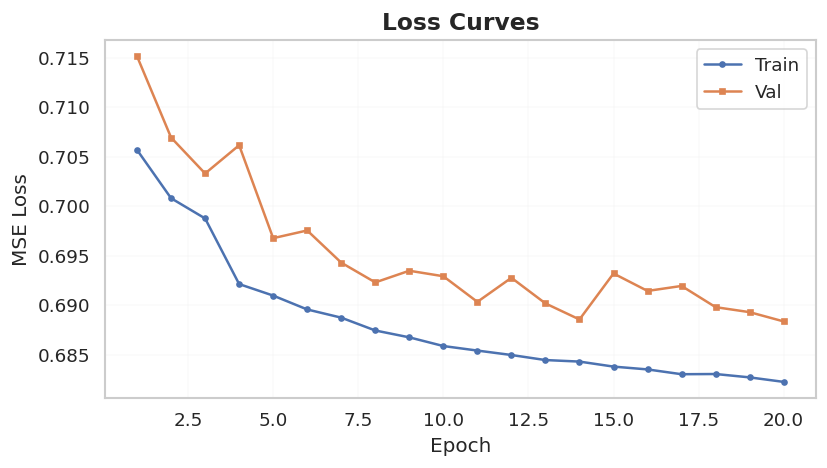

In [117]:
# ── Loss curves: scAlphaGenomeDecoder ─────────────────────────────────────────
epochs = range(1, N_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, main_history['train'], label='Train', marker='o', markersize=3)
ax.plot(epochs, main_history['val'],   label='Val',   marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Loss Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
@torch.no_grad()
def pearson_per_ct_main(model, organ_data, organ_list, gene_splits, device, chunk=256):
    """Pearson r per cell type (across val genes) for scAlphaGenomeDecoder.

    The model predicts z-scored labels; this function denormalizes predictions
    back to raw log-CPM per gene before computing Pearson.
    """
    model.eval()
    results = {}
    for organ in organ_list:
        oi       = ORGAN_IDX[organ]
        data     = organ_data[organ]
        val_idx  = gene_splits[organ]['val']
        n_val    = len(val_idx)
        n_ct     = data['scvi'].shape[0]
        scvi_t   = torch.FloatTensor(data['scvi']).to(device)  # [n_ct, 50]
        true_lab = data['labels'][:, val_idx]                  # [n_ct, n_val] raw log-CPM
        preds    = np.zeros((n_ct, n_val), dtype=np.float32)

        gene_mean = data['gene_mean'].ravel()[val_idx]   # [n_val]
        gene_std  = data['gene_std'].ravel()[val_idx]    # [n_val]

        # Chunk over val genes
        for start in range(0, n_val, chunk):
            end    = min(start + chunk, n_val)
            ag_c   = torch.FloatTensor(
                data['features'][val_idx[start:end]]).to(device)    # [c, 8192]
            B_c    = ag_c.shape[0]
            scvi_e = scvi_t.unsqueeze(0).expand(B_c, -1, -1)        # [c, n_ct, 50]
            pred_c_z = model(ag_c, scvi_e, organ_idx=oi).cpu().numpy() # [c, n_ct]
            # denormalize per-gene: pred_raw = pred_z * std + mean
            # pred_c_z: [c, n_ct] where c corresponds to genes in [start:end]
            pred_c_raw = (pred_c_z.T * gene_std[start:end]) + gene_mean[start:end]  # [n_ct, c]
            preds[:, start:end] = pred_c_raw

        pearson = np.array([pearsonr(preds[ct], true_lab[ct])[0] for ct in range(n_ct)])
        results[organ] = {
            'pearson'     : pearson,
            'ct_ids'      : data['cell_type_ids'],
            'ct_names'    : data['ct_names'],
            'mean_pearson': float(np.nanmean(pearson)),
        }
        print(f'{organ:8s}: mean Pearson r = {results[organ]["mean_pearson"]:.4f} '
              f'(n_ct={n_ct}, n_val_genes={n_val:,})')
    return results


print('Evaluating scAlphaGenomeDecoder...\n')
main_pearson = pearson_per_ct_main(main_model, organ_data, ORGAN_LIST, gene_splits, device)

Evaluating scAlphaGenomeDecoder...

heart   : mean Pearson r = 0.9183 (n_ct=15, n_val_genes=10,000)
heart   : mean Pearson r = 0.9183 (n_ct=15, n_val_genes=10,000)
kidney  : mean Pearson r = 0.9297 (n_ct=10, n_val_genes=10,000)
kidney  : mean Pearson r = 0.9297 (n_ct=10, n_val_genes=10,000)
liver   : mean Pearson r = 0.9394 (n_ct=22, n_val_genes=10,000)
liver   : mean Pearson r = 0.9394 (n_ct=22, n_val_genes=10,000)
lung    : mean Pearson r = 0.9449 (n_ct=29, n_val_genes=10,000)
lung    : mean Pearson r = 0.9449 (n_ct=29, n_val_genes=10,000)


## What does the MSE tell us?

Labels are **raw log-CPM** values (no z-scoring). The null baseline predicts the
per-gene mean expression across cell types — equivalent to ignoring cell-type identity.

| MSE (log-CPM²) | R² | Interpretation |
|----------------|-----|----------------|
| ≈ null MSE | ~0.0 | No better than predicting the per-gene mean |
| 0.5 × null | ~0.5 | Moderate — explaining half the cell-type variance |
| 0.3 × null | ~0.7 | Good |
| 0.1 × null | ~0.9 | Strong |

R² = 1 − MSE_model / MSE_null, where MSE_null = mean variance of expression across cell types per gene.
A high R² means the model correctly captures which cell types express each gene more or less than average.

In [46]:
@torch.no_grad()
def get_predictions(model, organ, organ_data, gene_splits, device, chunk=256):
    """Return (preds, true_labels) arrays of shape [n_ct, n_val_genes] for one organ.

    The model outputs z-scored predictions; this function denormalizes them to
    raw log-CPM using stored gene_mean/gene_std so downstream metrics operate on
    the same units as the baseline and true labels.
    """
    model.eval()
    oi       = ORGAN_IDX[organ]
    data     = organ_data[organ]
    val_idx  = gene_splits[organ]['val']
    n_val    = len(val_idx)
    n_ct     = data['scvi'].shape[0]
    scvi_t   = torch.FloatTensor(data['scvi']).to(device)
    true_lab = data['labels'][:, val_idx]              # [n_ct, n_val], raw log-CPM
    preds    = np.zeros((n_ct, n_val), dtype=np.float32)

    gene_mean = data['gene_mean'].ravel()[val_idx]   # [n_val]
    gene_std  = data['gene_std'].ravel()[val_idx]    # [n_val]

    for start in range(0, n_val, chunk):
        end    = min(start + chunk, n_val)
        ag_c   = torch.FloatTensor(data['features'][val_idx[start:end]]).to(device)
        B_c    = ag_c.shape[0]
        scvi_e = scvi_t.unsqueeze(0).expand(B_c, -1, -1)
        pred_c_z = model(ag_c, scvi_e, organ_idx=oi).cpu().numpy()  # [c, n_ct]
        pred_c_raw = (pred_c_z.T * gene_std[start:end]) + gene_mean[start:end]
        preds[:, start:end] = pred_c_raw

    return preds, true_lab   # preds and true_lab are raw log-CPM now


print('Collecting validation predictions for all organs...')
all_preds, all_true = {}, {}
for organ in ORGAN_LIST:
    all_preds[organ], all_true[organ] = get_predictions(
        main_model, organ, organ_data, gene_splits, device
    )
    print(f'  {organ}: preds {all_preds[organ].shape}')

  heart: preds (15, 10000)
  heart: preds (15, 10000)
  kidney: preds (10, 10000)
  kidney: preds (10, 10000)
  liver: preds (22, 10000)
  liver: preds (22, 10000)
  lung: preds (29, 10000)
  lung: preds (29, 10000)


In [47]:
# ── R² and null model comparison ──────────────────────────────────────────────
# Null: predict the per-gene mean expression across cell types.
# This is the best constant predictor for each gene that ignores cell-type identity.
# R² = 1 - MSE_model / MSE_null

print(f'  {"Organ":<10}  {"Val MSE":>9}  {"Null MSE":>9}  {"R²":>7}  {"Mean Pearson r":>15}')
print('  ' + '-' * 56)

for organ in ORGAN_LIST:
    true_val  = organ_data[organ]['labels'][:, gene_splits[organ]['val']]  # [n_ct, n_val]
    gene_mean = true_val.mean(axis=0, keepdims=True)                        # [1, n_val]
    null_mse  = float(np.mean((true_val - gene_mean) ** 2))
    model_mse = float(np.mean((all_preds[organ] - true_val) ** 2))
    r2        = 1.0 - model_mse / null_mse
    mean_r    = main_pearson[organ]['mean_pearson']
    print(f'  {organ:<10}  {model_mse:>9.4f}  {null_mse:>9.4f}  {r2:>7.4f}  {mean_r:>15.4f}')

print()
print('  Null = predicting per-gene mean across cell types (best cell-type-agnostic baseline).')
print('  R² > 0 means the model adds cell-type specificity beyond the per-gene mean.')

  Organ         Val MSE   Null MSE       R²   Mean Pearson r
  --------------------------------------------------------
  heart          0.3202     0.3685   0.1311           0.9183
  kidney         0.3103     0.3133   0.0095           0.9297
  liver          0.2558     0.2618   0.0233           0.9394
  lung           0.2344     0.2425   0.0334           0.9449

  Null = predicting per-gene mean across cell types (best cell-type-agnostic baseline).
  R² > 0 means the model adds cell-type specificity beyond the per-gene mean.


In [114]:
print(ORGAN_LIST)

['heart', 'kidney', 'liver', 'lung']


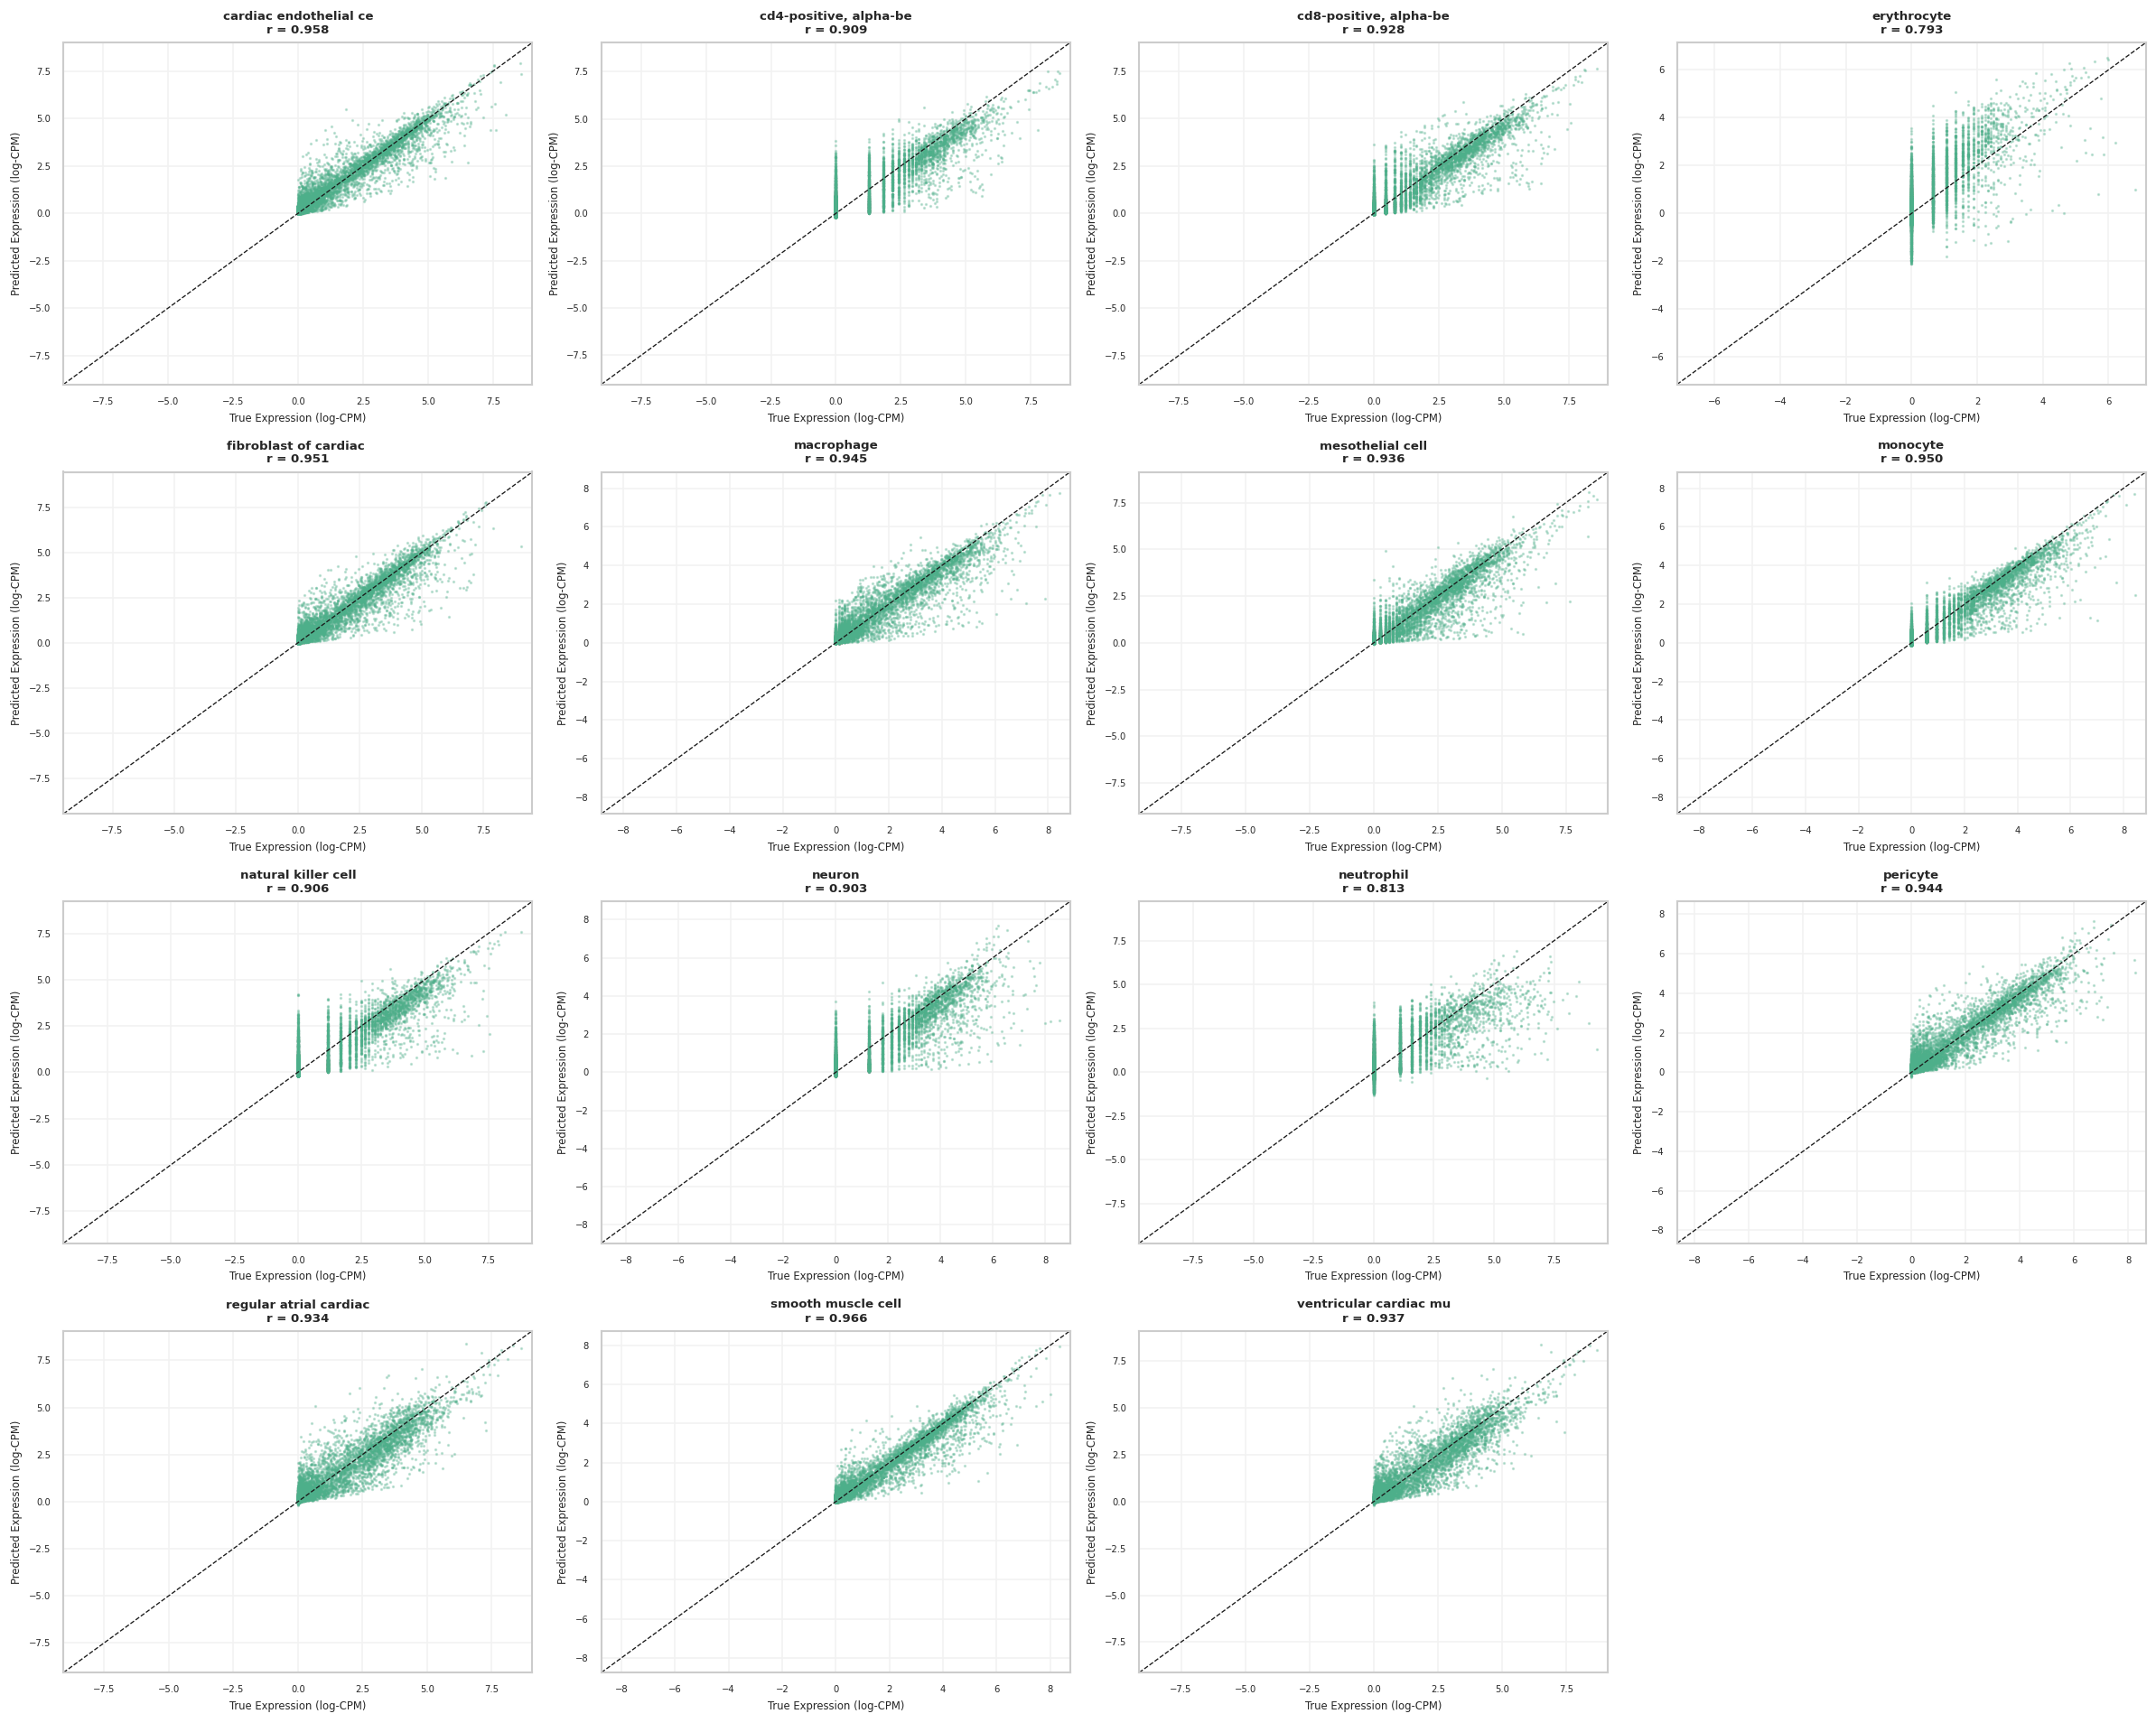

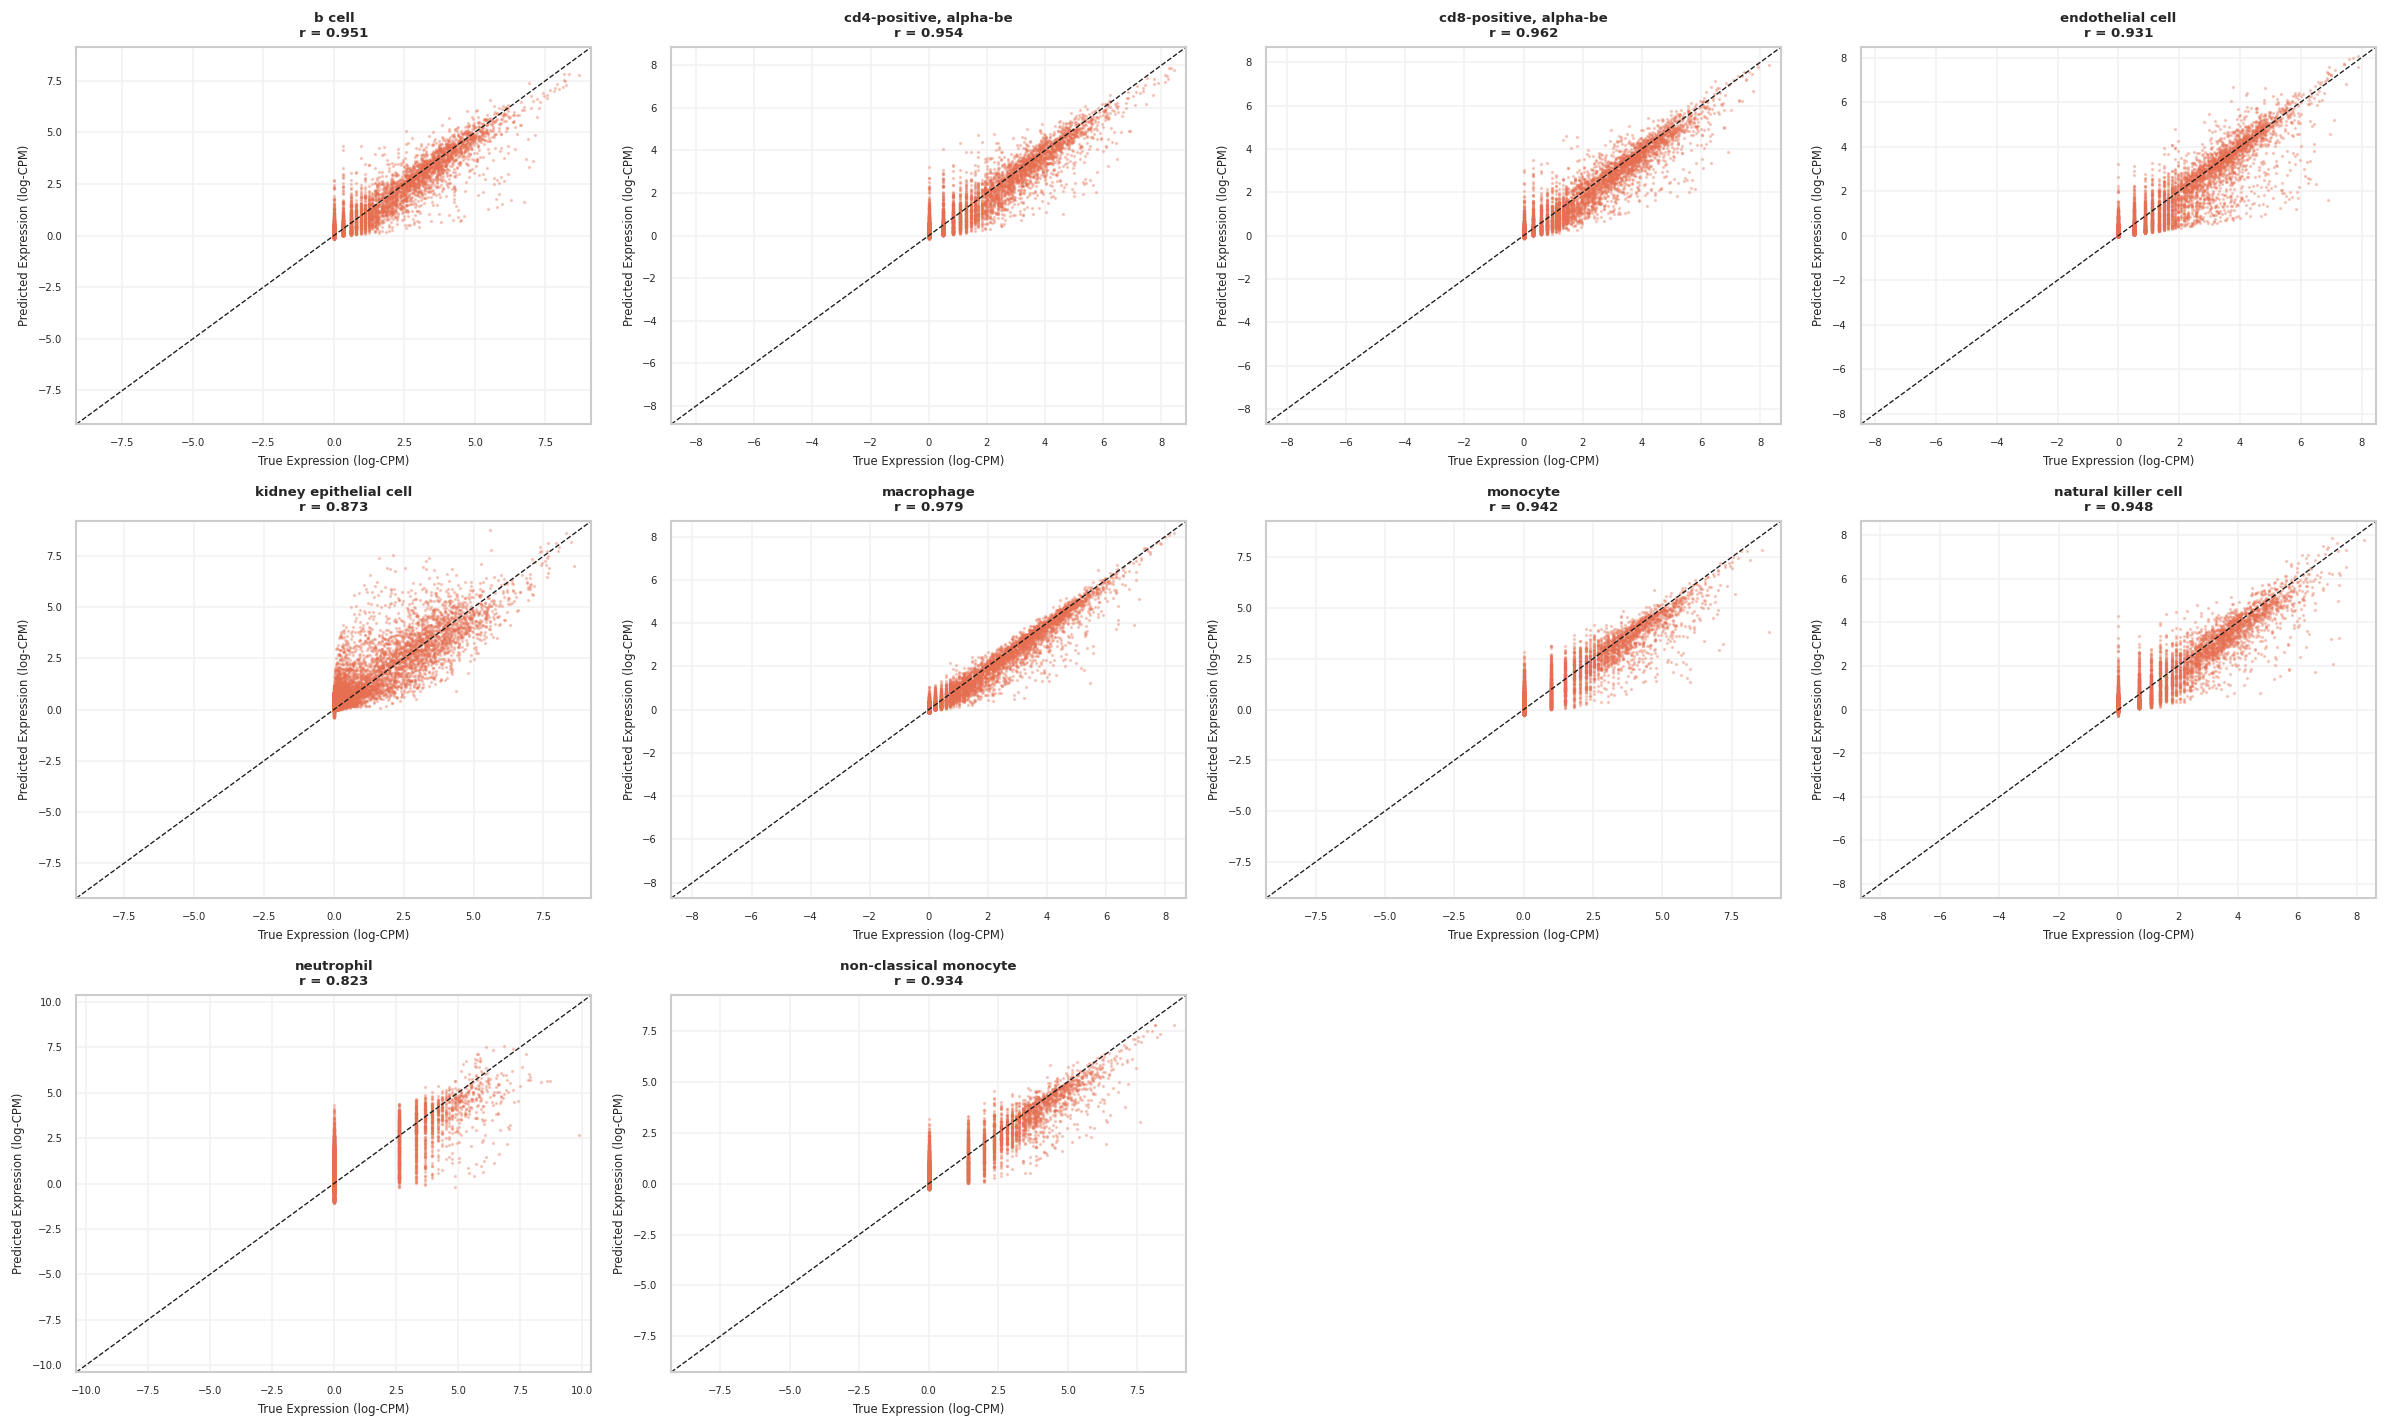

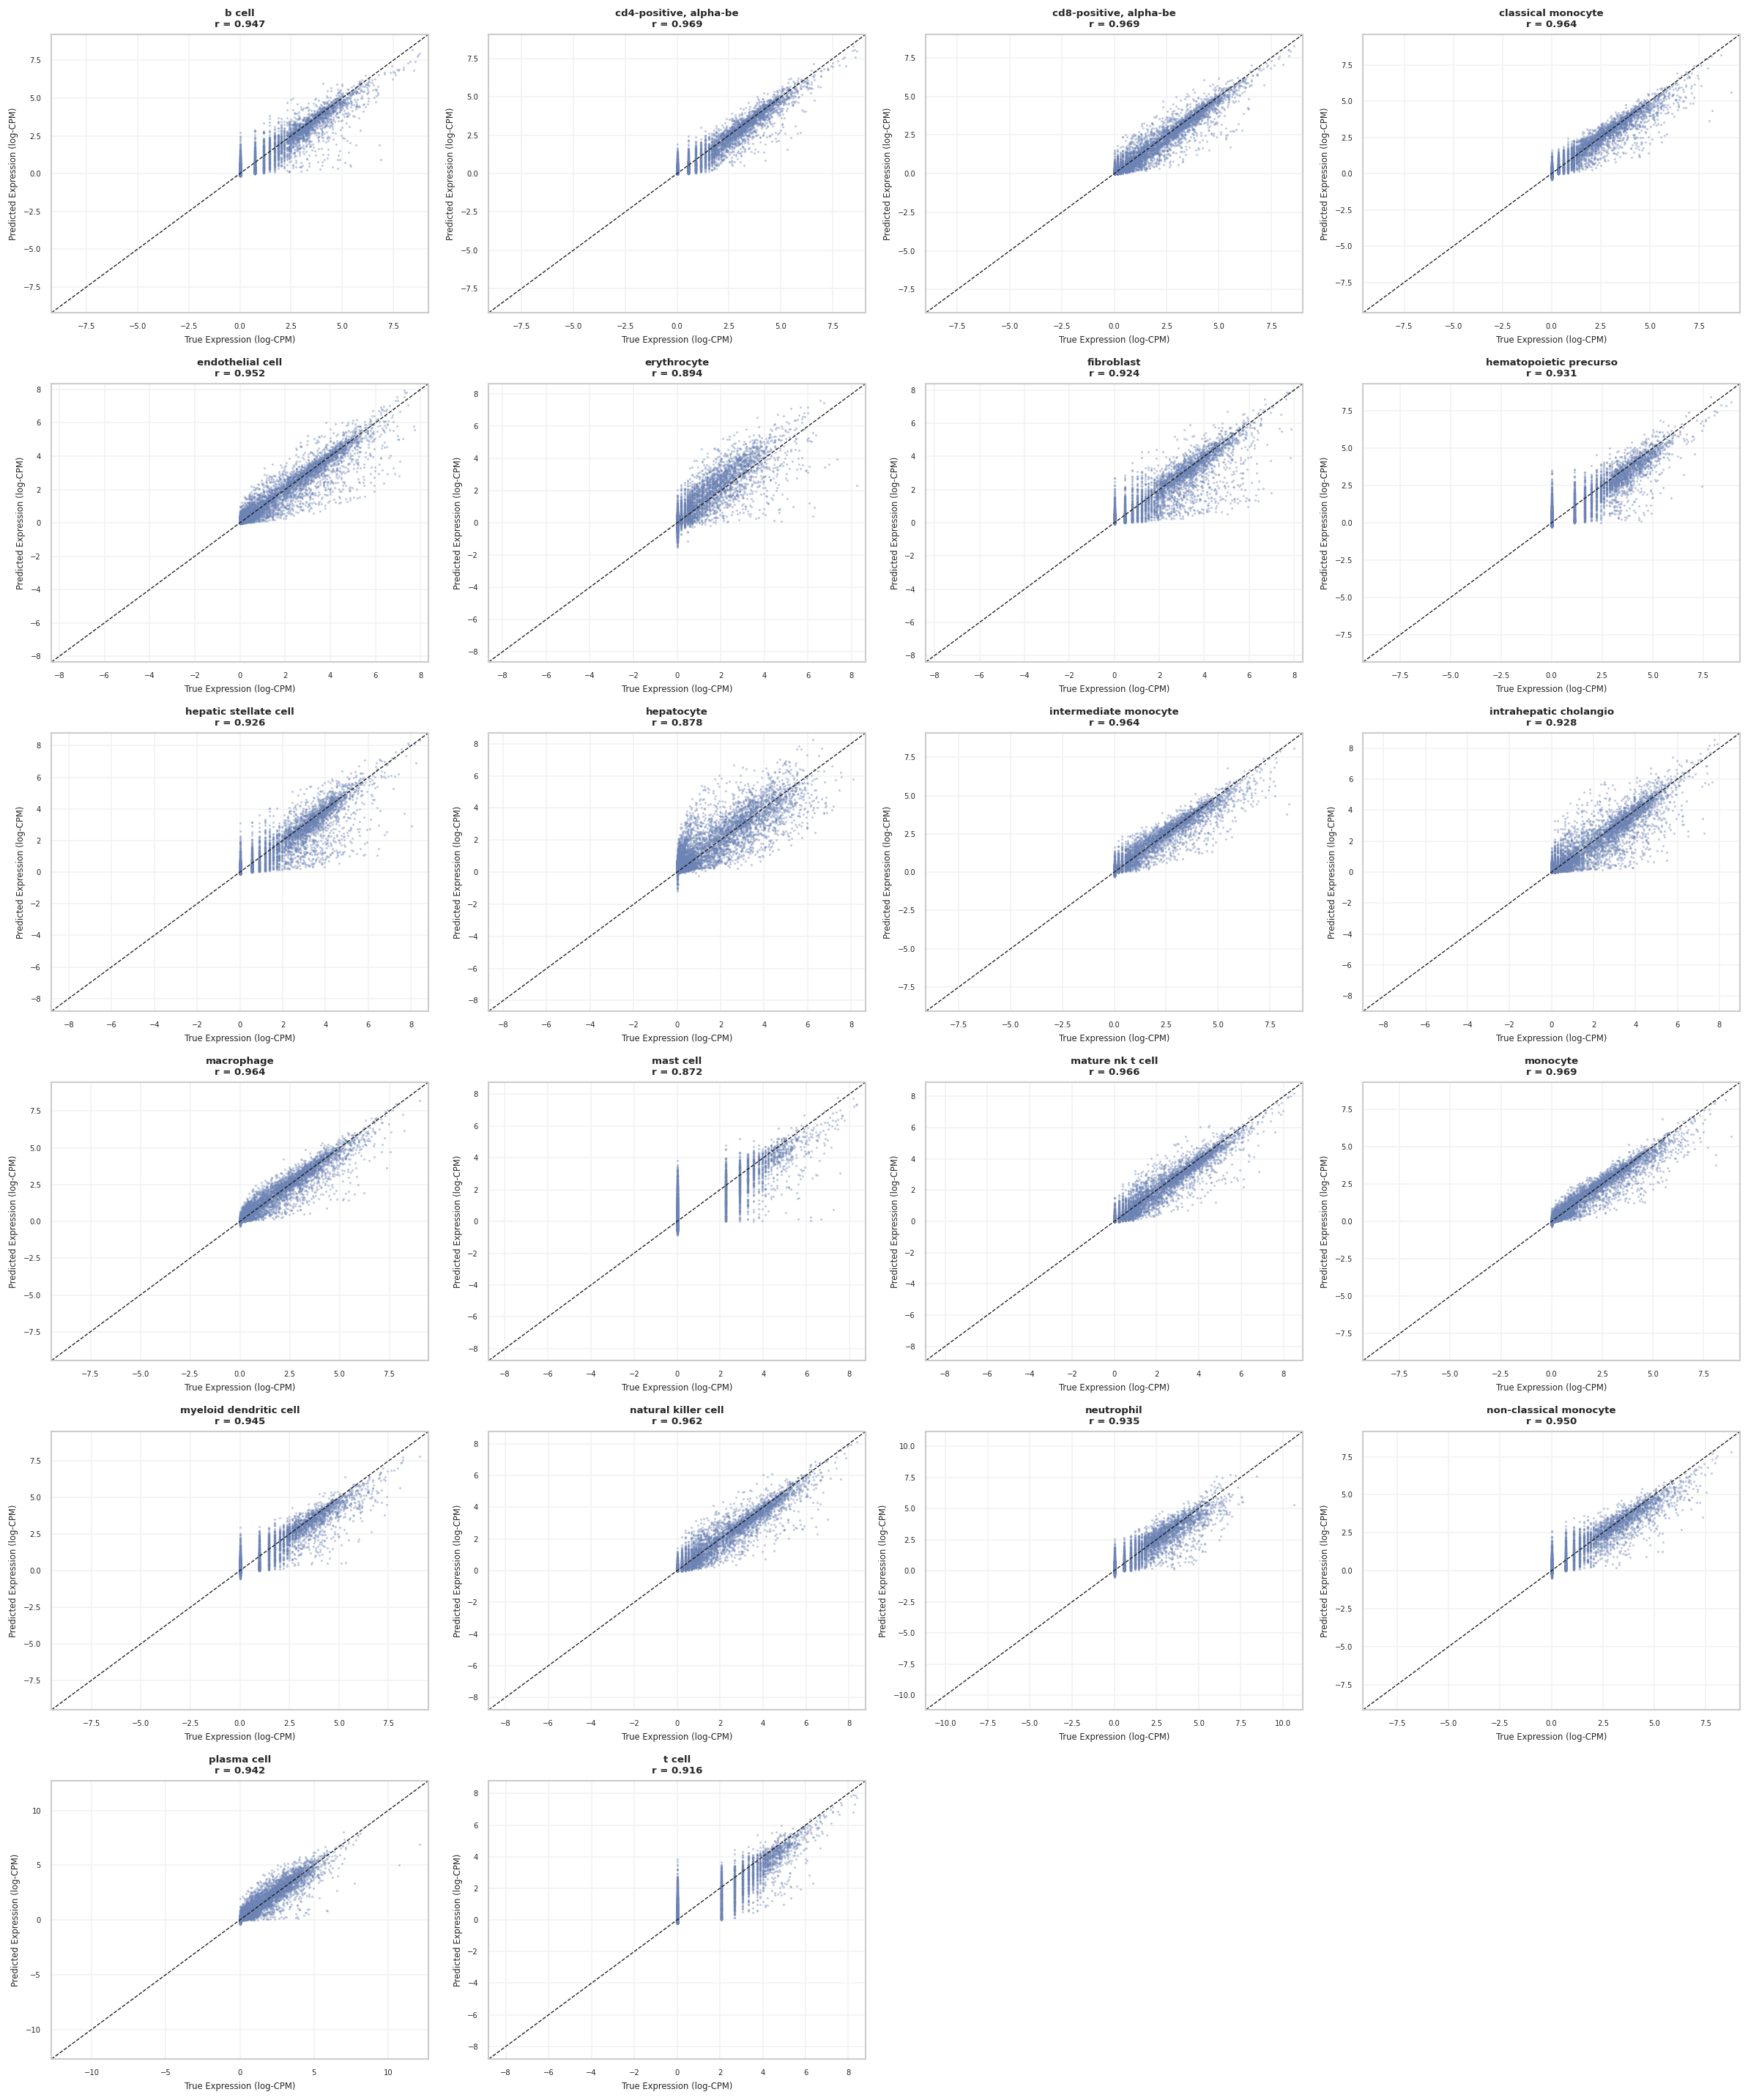

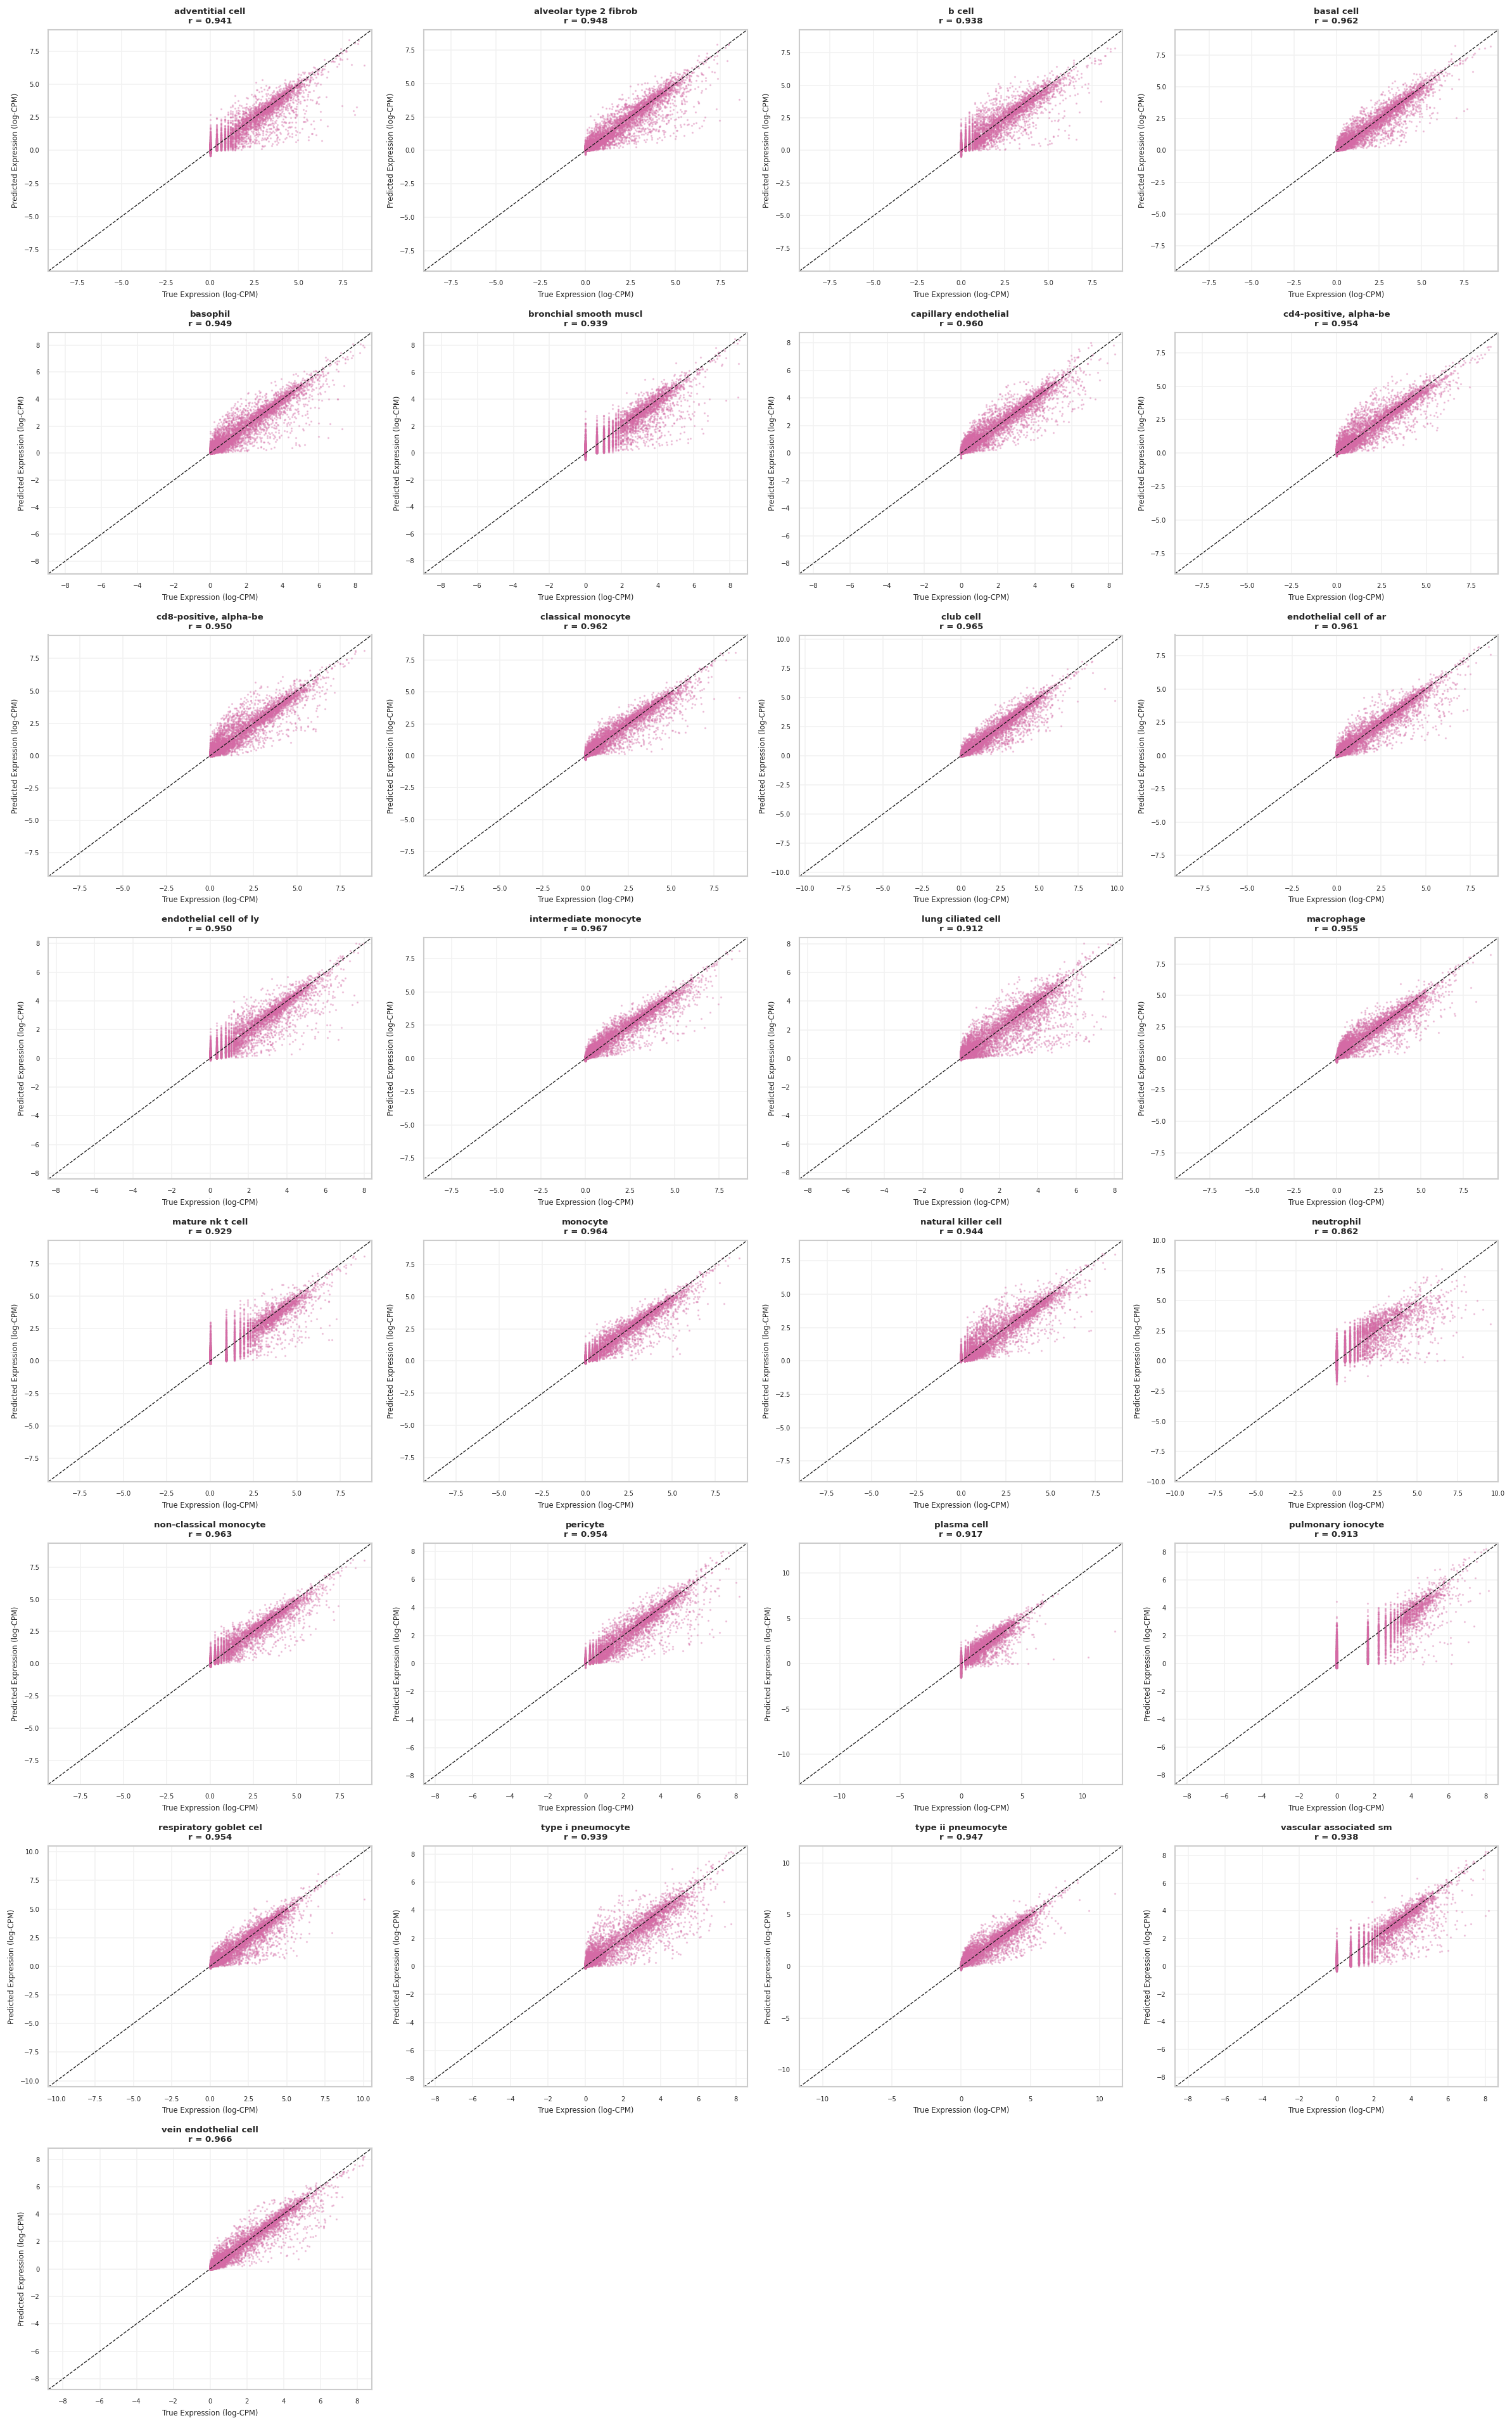

In [112]:
# ── Predicted vs true scatter: one organ, all cell types ─────────────────────
ORGAN_COLORS_DARK = [
    '#4daf8a', 
    '#e76f51', 
    '#6c83b5', 
    '#d46aa5', 
]
for i in range(len(ORGAN_LIST)):
    SCATTER_ORGAN = ORGAN_LIST[i]
    ORGAN_COLOR = ORGAN_COLORS_DARK[i]
    preds_s  = all_preds[SCATTER_ORGAN]   # [n_ct, n_val], raw log-CPM predictions
    true_s   = all_true[SCATTER_ORGAN]    # [n_ct, n_val], raw log-CPM
    ct_names = main_pearson[SCATTER_ORGAN]['ct_names']
    n_ct     = preds_s.shape[0]

    ncols = min(n_ct, 4)
    nrows = (n_ct + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ct_i in range(n_ct):
        ax = axes[ct_i]
        p  = preds_s[ct_i]
        t  = true_s[ct_i]
        r  = main_pearson[SCATTER_ORGAN]['pearson'][ct_i]
        ax.scatter(t, p, s=1, alpha=0.3, rasterized=True, color=ORGAN_COLOR)
        lim = max(abs(t).max(), abs(p).max()) * 1.05
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8)
        ax.set_title(f'{str(ct_names[ct_i])[:22]}\nr = {r:.3f}', fontsize=8)
        ax.set_xlabel('True Expression (log-CPM)', fontsize=7)
        ax.set_ylabel('Predicted Expression (log-CPM)', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

    for ax in axes[n_ct:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

heart   :  median gene r = 0.386  |  88% genes with r > 0  |  high-var genes (top 25%) mean r = 0.425  |  low-var genes (bot 25%) mean r = 0.352
kidney  :  median gene r = 0.427  |  80% genes with r > 0  |  high-var genes (top 25%) mean r = 0.296  |  low-var genes (bot 25%) mean r = 0.681
kidney  :  median gene r = 0.427  |  80% genes with r > 0  |  high-var genes (top 25%) mean r = 0.296  |  low-var genes (bot 25%) mean r = 0.681
liver   :  median gene r = 0.274  |  83% genes with r > 0  |  high-var genes (top 25%) mean r = 0.246  |  low-var genes (bot 25%) mean r = 0.396
liver   :  median gene r = 0.274  |  83% genes with r > 0  |  high-var genes (top 25%) mean r = 0.246  |  low-var genes (bot 25%) mean r = 0.396
lung    :  median gene r = 0.247  |  84% genes with r > 0  |  high-var genes (top 25%) mean r = 0.249  |  low-var genes (bot 25%) mean r = 0.161
lung    :  median gene r = 0.247  |  84% genes with r > 0  |  high-var genes (top 25%) mean r = 0.249  |  low-var genes (bot 25%) 

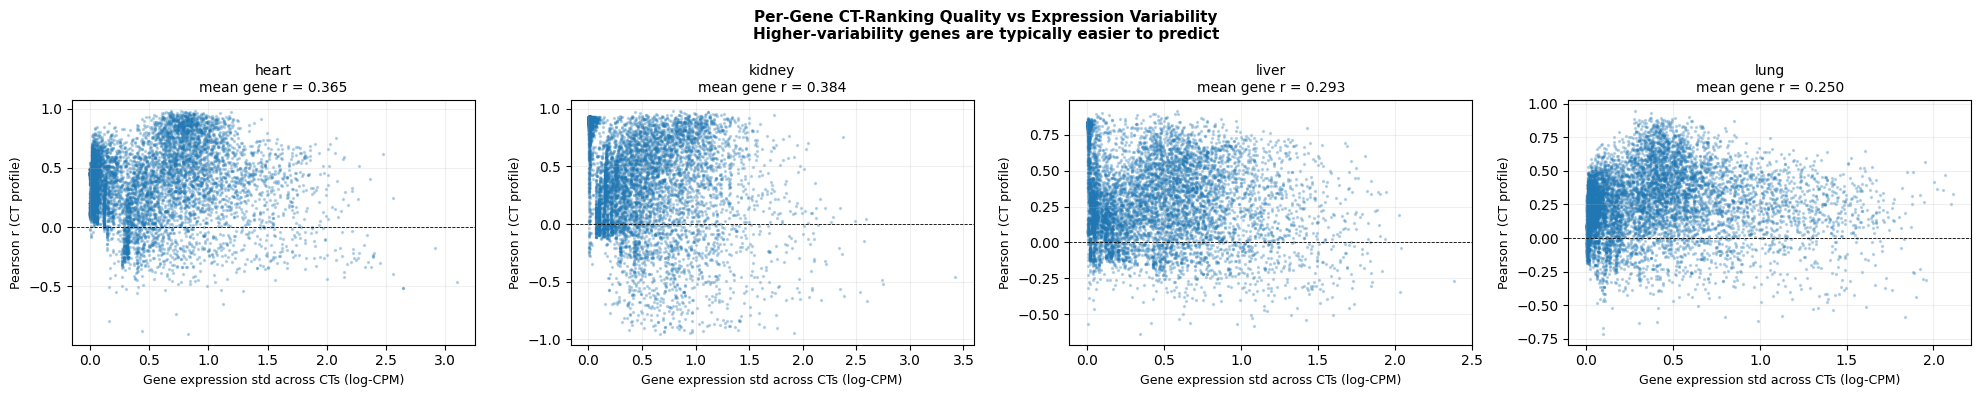

In [49]:
# Per-gene CT-ranking quality & expression variability vs performance
# For each organ: compute per-gene Pearson r between predicted CT profile and true CT profile
# and plot that against the gene's expression std across CTs. Predictions and true labels
# are both in raw log-CPM (denormalized).

fig, axes = plt.subplots(1, len(ORGAN_LIST), figsize=(5 * len(ORGAN_LIST), 4), sharey=False)
if len(ORGAN_LIST) == 1:
    axes = [axes]

for ax, organ in zip(axes, ORGAN_LIST):
    p     = all_preds[organ]      # [n_ct, n_val], raw log-CPM
    t_raw = all_true[organ]       # [n_ct, n_val], raw log-CPM
    n_val = p.shape[1]
    n_ct  = p.shape[0]

    # Per-gene Pearson r (across cell types): shape [n_val]
    gene_r = np.array([
        pearsonr(p[:, g], t_raw[:, g])[0] if n_ct > 2 else float('nan')
        for g in range(n_val)
    ])

    # Gene expression variability: std of raw log-CPM across CTs
    gene_std = t_raw.std(axis=0)   # [n_val]

    # Remove NaNs
    mask = np.isfinite(gene_r) & np.isfinite(gene_std)
    gene_r, gene_std = gene_r[mask], gene_std[mask]

    # Scatter: variability vs per-gene r
    ax.scatter(gene_std, gene_r, s=2, alpha=0.25, rasterized=True)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_xlabel('Gene expression std across CTs (log-CPM)', fontsize=9)
    ax.set_ylabel('Pearson r (CT profile)', fontsize=9)
    ax.set_title(f'{organ}\nmean gene r = {np.nanmean(gene_r):.3f}', fontsize=10)
    ax.grid(alpha=0.2)

    # Print summary
    pct_pos = (gene_r > 0).mean() * 100
    print(f'{organ:8s}:  median gene r = {np.nanmedian(gene_r):.3f}  '
          f'|  {pct_pos:.0f}% genes with r > 0  '
          f'|  high-var genes (top 25%) mean r = '
          f'{gene_r[gene_std > np.percentile(gene_std, 75)].mean():.3f}  '
          f'|  low-var genes (bot 25%) mean r = '
          f'{gene_r[gene_std < np.percentile(gene_std, 25)].mean():.3f}')

plt.suptitle('Per-Gene CT-Ranking Quality vs Expression Variability\n'
             'Higher-variability genes are typically easier to predict',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Part 2: AGCellBaseline — Training & Comparison
#
Trains a simple MLP on AlphaGenome's own cell-type-conditioned sequence tracks
(CL-term conditioning, heart only on GCS).  Then compares Pearson r against
the scAlphaGenomeDecoder on the overlapping cell types to show:
1. Quality advantage — our model ≥ baseline on AG-supported CTs
2. Coverage advantage — our model covers far more cell types

In [50]:
from google.colab import auth
auth.authenticate_user()

In [51]:
# ── Load agcell data (heart only) from Google Cloud Storage ───────────────────
# agcell uses AlphaGenome with CL-term conditioning for each supported cell type.
# Format: features [n_supported_ct, n_genes, 8192], labels [n_supported_ct, n_genes]

import io
from google.cloud import storage as gcs

GCP_PROJECT  = 'scalphagenome'
GCS_BUCKET   = 'scalphagenome-data'
AGCELL_ORGAN = 'heart'
AGCELL_BLOB  = f'{AGCELL_ORGAN}_{ASSAY}_base_ag.npz'

print(f'Downloading gs://{GCS_BUCKET}/{AGCELL_BLOB} ...')
gcs_client = gcs.Client(project=GCP_PROJECT)
bucket     = gcs_client.bucket(GCS_BUCKET)
blob       = bucket.blob(AGCELL_BLOB)
npz_bytes  = blob.download_as_bytes()
agcell_raw = np.load(io.BytesIO(npz_bytes), allow_pickle=True)
print('Download complete.')

print('agcell files:', agcell_raw.files)
for k in agcell_raw.files:
    v = agcell_raw[k]
    print(f'  {k}: {v.shape if hasattr(v, "shape") else v}')

agcell_feat   = agcell_raw['features'].astype(np.float32)  # [n_sup_ct, n_genes, 8192]
agcell_labels = agcell_raw['labels'].astype(np.float32)    # [n_sup_ct, n_genes]
agcell_gids   = agcell_raw['gene_ids']                      # [n_genes]
agcell_ctids  = agcell_raw['cell_type_ids']                 # [n_sup_ct]

print(f'\nSupported CTs: {list(agcell_ctids)}')

Download complete.
agcell files: ['features', 'labels', 'gene_ids', 'cell_type_ids', 'resolution_bp']
Download complete.
agcell files: ['features', 'labels', 'gene_ids', 'cell_type_ids', 'resolution_bp']
  features: (4, 50000, 8192)
  labels: (4, 50000)
  gene_ids: (50000,)
  cell_type_ids: (4,)
  resolution_bp: ()
  features: (4, 50000, 8192)
  labels: (4, 50000)
  gene_ids: (50000,)
  cell_type_ids: (4,)
  resolution_bp: ()

Supported CTs: ['CL:0000624', 'CL:0000625', 'CL:0000623', 'CL:0000192']

Supported CTs: ['CL:0000624', 'CL:0000625', 'CL:0000623', 'CL:0000192']


In [52]:
# ── Align agcell genes with the heart uberon gene split ───────────────────────
heart_gids  = organ_data['heart']['gene_ids']
gid_to_ag   = {g: i for i, g in enumerate(heart_gids)}
gid_to_cell = {g: i for i, g in enumerate(agcell_gids)}

shared_genes   = [g for g in heart_gids if g in gid_to_cell]
ag_gene_map    = np.array([gid_to_ag[g]   for g in shared_genes])
cell_gene_map  = np.array([gid_to_cell[g] for g in shared_genes])

print(f'Shared genes (agcell ∩ uberon): {len(shared_genes):,} / {len(heart_gids):,}')

# Re-index agcell to shared gene order
agcell_feat_aligned   = agcell_feat[:, cell_gene_map, :]         # [n_sup_ct, n_shared, 8192]
agcell_labels_aligned = agcell_labels[:, cell_gene_map].astype(np.float32)  # [n_sup_ct, n_shared]

# Map heart gene-split indices to shared_genes indices
ag_gene_pos    = {v: i for i, v in enumerate(ag_gene_map)}
cell_train_idx = np.array([ag_gene_pos[i] for i in gene_splits['heart']['train'] if i in ag_gene_pos])
cell_val_idx   = np.array([ag_gene_pos[i] for i in gene_splits['heart']['val']   if i in ag_gene_pos])
print(f'Baseline train genes: {len(cell_train_idx):,} | val genes: {len(cell_val_idx):,}')

# DataLoaders — raw log-CPM labels, no z-scoring
bl_train_loader = DataLoader(
    AGCellDataset(agcell_feat_aligned, agcell_labels_aligned, cell_train_idx),
    batch_size=GENE_BATCH, shuffle=True,  num_workers=2, pin_memory=True,
)
bl_val_loader = DataLoader(
    AGCellDataset(agcell_feat_aligned, agcell_labels_aligned, cell_val_idx),
    batch_size=GENE_BATCH, shuffle=False, num_workers=2, pin_memory=True,
)

baseline_model = AGCellBaseline(n_bins=AG_BINS).to(device)
n_params_bl    = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'\nAGCellBaseline parameters: {n_params_bl:,}')
optimizer_bl = torch.optim.Adam(baseline_model.parameters(), lr=LR)

Shared genes (agcell ∩ uberon): 50,000 / 50,000
Baseline train genes: 40,000 | val genes: 10,000

AGCellBaseline parameters: 2,113,921
Baseline train genes: 40,000 | val genes: 10,000

AGCellBaseline parameters: 2,113,921


In [53]:
print(f'Training AGCellBaseline on {AGCELL_ORGAN}\n')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}')
print('-' * 36)

bl_history = {'train': [], 'val': []}

for epoch in range(1, N_EPOCHS + 1):
    t_loss = train_baseline_epoch(baseline_model, bl_train_loader, optimizer_bl, device)
    v_loss = eval_baseline_epoch(baseline_model, bl_val_loader, device)
    bl_history['train'].append(t_loss)
    bl_history['val'].append(v_loss)
    print(f'{epoch:>6}  {t_loss:>12.5f}  {v_loss:>10.5f}')

print('\nTraining complete.')

Training AGCellBaseline on heart

 Epoch    Train Loss    Val Loss
------------------------------------
     1       2.06965     1.90178
     1       2.06965     1.90178
     2       1.77888     1.79325
     2       1.77888     1.79325
     3       1.67321     1.76622
     3       1.67321     1.76622
     4       1.60438     1.75973
     4       1.60438     1.75973
     5       1.54641     1.76476
     5       1.54641     1.76476
     6       1.48445     1.77421
     6       1.48445     1.77421
     7       1.42827     1.78682
     7       1.42827     1.78682
     8       1.37194     1.81688
     8       1.37194     1.81688
     9       1.31733     1.84713
     9       1.31733     1.84713
    10       1.26245     1.86441
    10       1.26245     1.86441
    11       1.20488     1.87591
    11       1.20488     1.87591
    12       1.15002     1.90020
    12       1.15002     1.90020
    13       1.09236     1.97165
    13       1.09236     1.97165
    14       1.04029     1.94594
    1

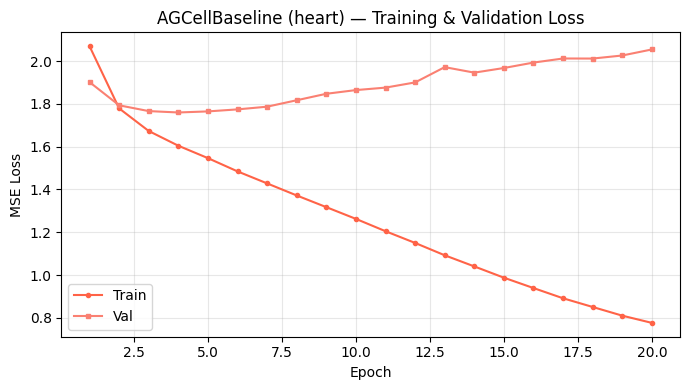

Saved baseline_loss_curves.png


In [54]:
# ── Loss curves: AGCellBaseline ────────────────────────────────────────────────
epochs = range(1, N_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, bl_history['train'], label='Train', marker='o', markersize=3, color='tomato')
ax.plot(epochs, bl_history['val'],   label='Val',   marker='s', markersize=3, color='salmon')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'AGCellBaseline ({AGCELL_ORGAN}) — Training & Validation Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved baseline_loss_curves.png')

In [55]:
@torch.no_grad()
def pearson_per_ct_baseline(model, agcell_feat, agcell_labels_raw,
                             agcell_ctids, cell_val_idx, device, chunk=256):
    """Pearson r per cell type (across val genes) for AGCellBaseline."""
    model.eval()
    n_ct  = agcell_feat.shape[0]
    n_val = len(cell_val_idx)
    true_lab = agcell_labels_raw[:, cell_val_idx]   # [n_ct, n_val] raw
    preds    = np.zeros((n_ct, n_val), dtype=np.float32)

    for start in range(0, n_val, chunk):
        end    = min(start + chunk, n_val)
        gi     = cell_val_idx[start:end]
        ag_c   = torch.FloatTensor(agcell_feat[:, gi, :]).permute(1, 0, 2).to(device)  # [c, n_ct, 8192]
        pred_c = model(ag_c).cpu().numpy()  # [c, n_ct]
        preds[:, start:end] = pred_c.T

    pearson = np.array([pearsonr(preds[ct], true_lab[ct])[0] for ct in range(n_ct)])
    print(f'AGCellBaseline heart: mean Pearson r = {np.nanmean(pearson):.4f} '
          f'(n_ct={n_ct}, n_val_genes={n_val:,})')
    return {'pearson': pearson, 'ct_ids': agcell_ctids, 'mean_pearson': float(np.nanmean(pearson))}


print('Evaluating AGCellBaseline...\n')
bl_pearson = pearson_per_ct_baseline(
    baseline_model, agcell_feat_aligned, agcell_labels_aligned,
    agcell_ctids, cell_val_idx, device,
)

Evaluating AGCellBaseline...

AGCellBaseline heart: mean Pearson r = 0.4416 (n_ct=4, n_val_genes=10,000)
AGCellBaseline heart: mean Pearson r = 0.4416 (n_ct=4, n_val_genes=10,000)


In [56]:
# ── Apples-to-apples: restrict to cell types present in BOTH models ────────────
# main_model was trained on uberon_ag cell types (all heart CTs from pseudobulk)
# baseline was trained on agcell cell types (only AG-supported CTs)

main_ct_set  = set(main_pearson['heart']['ct_ids'])
bl_ct_set    = set(bl_pearson['ct_ids'])
overlap_cts  = sorted(main_ct_set & bl_ct_set)

print(f'Cell types in main model (heart): {len(main_ct_set)}')
print(f'Cell types in AGCellBaseline:      {len(bl_ct_set)}')
print(f'Overlap (used for comparison):     {len(overlap_cts)}')
print(f'Overlap CTs: {overlap_cts}\n')

# Gather Pearson r for the overlapping cell types
main_r_dict = dict(zip(main_pearson['heart']['ct_ids'],
                       main_pearson['heart']['pearson']))
bl_r_dict   = dict(zip(bl_pearson['ct_ids'], bl_pearson['pearson']))

comp_main = np.array([main_r_dict[ct] for ct in overlap_cts])
comp_bl   = np.array([bl_r_dict[ct]   for ct in overlap_cts])

ct_labels = overlap_cts  # use raw CL IDs; replace with names if available
if 'ct_names' in main_pearson['heart']:
    name_map = dict(zip(main_pearson['heart']['ct_ids'], main_pearson['heart']['ct_names']))
    ct_labels = [name_map.get(ct, ct) for ct in overlap_cts]

print('Comparison on overlapping cell types:')
print(f'{"Cell type":<40}  {"scAlphaGenome":>14}  {"AGCell Baseline":>15}')
print('-' * 75)
for ct, nm, r_m, r_b in zip(overlap_cts, ct_labels, comp_main, comp_bl):
    print(f'{nm:<40}  {r_m:>14.4f}  {r_b:>15.4f}')
print('-' * 75)
print(f'{"Mean":<40}  {comp_main.mean():>14.4f}  {comp_bl.mean():>15.4f}')

Cell types in main model (heart): 15
Cell types in AGCellBaseline:      4
Overlap (used for comparison):     4
Overlap CTs: ['CL:0000192', 'CL:0000623', 'CL:0000624', 'CL:0000625']

Comparison on overlapping cell types:
Cell type                                  scAlphaGenome  AGCell Baseline
---------------------------------------------------------------------------
smooth muscle cell                                0.9660           0.3338
natural killer cell                               0.9063           0.6060
cd4-positive, alpha-beta t cell                   0.9091           0.4020
cd8-positive, alpha-beta t cell                   0.9283           0.4247
---------------------------------------------------------------------------
Mean                                              0.9274           0.4416


In [57]:
# ── Collect baseline predictions & align both models to shared CTs / val genes ─
# All predictions are on raw log-CPM scale — no denormalization needed.

from scipy.stats import spearmanr

@torch.no_grad()
def get_bl_preds(model, agcell_feat, cell_val_idx, device, chunk=256):
    """Return raw log-CPM predictions [n_ct, n_val] from the baseline model."""
    model.eval()
    n_ct   = agcell_feat.shape[0]
    n_val  = len(cell_val_idx)
    preds  = np.zeros((n_ct, n_val), dtype=np.float32)
    for start in range(0, n_val, chunk):
        end    = min(start + chunk, n_val)
        gi     = cell_val_idx[start:end]
        ag_c   = torch.FloatTensor(agcell_feat[:, gi, :]).permute(1, 0, 2).to(device)
        pred_c = model(ag_c).cpu().numpy()
        preds[:, start:end] = pred_c.T
    return preds

bl_preds_all = get_bl_preds(baseline_model, agcell_feat_aligned, cell_val_idx, device)

# Map overlap_cts → indices in each model's CT list
heart_ct_ids = organ_data['heart']['cell_type_ids']
main_ct_map  = {ct: i for i, ct in enumerate(heart_ct_ids)}
bl_ct_map    = {ct: i for i, ct in enumerate(agcell_ctids)}
ov_main_idx  = np.array([main_ct_map[ct] for ct in overlap_cts])
ov_bl_idx    = np.array([bl_ct_map[ct]   for ct in overlap_cts])

n_val_shared = min(all_preds['heart'].shape[1], bl_preds_all.shape[1])

p_main = all_preds['heart'][ov_main_idx, :n_val_shared]   # [n_ov, n_val] raw log-CPM
p_bl   = bl_preds_all[ov_bl_idx,          :n_val_shared]   # [n_ov, n_val] raw log-CPM
t_raw  = organ_data['heart']['labels'][ov_main_idx, :n_val_shared]  # [n_ov, n_val] true

print(f'Aligned: {len(overlap_cts)} shared CTs, {n_val_shared:,} val genes')
print(f'Shape check — main: {p_main.shape}, baseline: {p_bl.shape}, true: {t_raw.shape}')

Aligned: 4 shared CTs, 10,000 val genes
Shape check — main: (4, 10000), baseline: (4, 10000), true: (4, 10000)


In [58]:
# ── Extended metrics: Pearson r, Spearman r, MAE, RMSE, CCC ──────────────────

def concordance_corr(y_true, y_pred):
    """Concordance correlation coefficient — measures both correlation and agreement."""
    mu_t, mu_p   = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(),  y_pred.var()
    cov          = np.cov(y_true, y_pred)[0, 1]
    return 2 * cov / (var_t + var_p + (mu_t - mu_p) ** 2 + 1e-9)

rows = []
for i, (ct, nm) in enumerate(zip(overlap_cts, ct_labels)):
    t, pm, pb = t_raw[i], p_main[i], p_bl[i]
    rows.append({
        'cell_type'    : nm,
        'pearson_main' : pearsonr(t, pm)[0],        'pearson_bl' : pearsonr(t, pb)[0],
        'spearman_main': spearmanr(t, pm).statistic, 'spearman_bl': spearmanr(t, pb).statistic,
        'mae_main'     : np.mean(np.abs(pm - t)),    'mae_bl'     : np.mean(np.abs(pb - t)),
        'rmse_main'    : np.sqrt(np.mean((pm - t)**2)),
        'rmse_bl'      : np.sqrt(np.mean((pb - t)**2)),
        'ccc_main'     : concordance_corr(t, pm),    'ccc_bl'    : concordance_corr(t, pb),
    })
df_metrics = pd.DataFrame(rows).set_index('cell_type')

hdr = (f'  {"Cell type":<36}  '
       f'{"Pearson r":>10}  {"Spearman r":>11}  '
       f'{"MAE (logCPM)":>13}  {"RMSE (logCPM)":>14}  {"CCC":>8}')
print(hdr)
print('  ' + '─' * (len(hdr) - 2))
for nm, row in df_metrics.iterrows():
    print(f'  {str(nm):<36}  '
          f'{row.pearson_main:>5.3f}/{row.pearson_bl:<5.3f}  '
          f'{row.spearman_main:>6.3f}/{row.spearman_bl:<5.3f}  '
          f'{row.mae_main:>6.3f}/{row.mae_bl:<6.3f}  '
          f'{row.rmse_main:>7.3f}/{row.rmse_bl:<6.3f}  '
          f'{row.ccc_main:>4.3f}/{row.ccc_bl:<4.3f}')
print('  ' + '─' * (len(hdr) - 2))
means = df_metrics.mean()
print(f'  {"Mean":<36}  '
      f'{means.pearson_main:>5.3f}/{means.pearson_bl:<5.3f}  '
      f'{means.spearman_main:>6.3f}/{means.spearman_bl:<5.3f}  '
      f'{means.mae_main:>6.3f}/{means.mae_bl:<6.3f}  '
      f'{means.rmse_main:>7.3f}/{means.rmse_bl:<6.3f}  '
      f'{means.ccc_main:>4.3f}/{means.ccc_bl:<4.3f}')
print('\n  Format: scAlphaGenome / AGCell Baseline   |   all units: raw log-CPM')

  Cell type                              Pearson r   Spearman r   MAE (logCPM)   RMSE (logCPM)       CCC
  ──────────────────────────────────────────────────────────────────────────────────────────────────────
  smooth muscle cell                    0.009/0.006   0.013/0.001   2.281/2.216     2.805/2.708   0.006/0.003
  natural killer cell                   0.011/-0.002   0.009/-0.004   2.218/2.104     2.822/2.637   0.007/-0.001
  cd4-positive, alpha-beta t cell       0.014/0.004   0.010/0.006   2.159/2.060     2.748/2.580   0.010/0.002
  cd8-positive, alpha-beta t cell       0.013/0.010   0.008/0.011   2.209/2.113     2.772/2.638   0.009/0.006
  ──────────────────────────────────────────────────────────────────────────────────────────────────────
  Mean                                  0.012/0.004   0.010/0.004   2.217/2.123     2.787/2.641   0.008/0.002

  Format: scAlphaGenome / AGCell Baseline   |   all units: raw log-CPM


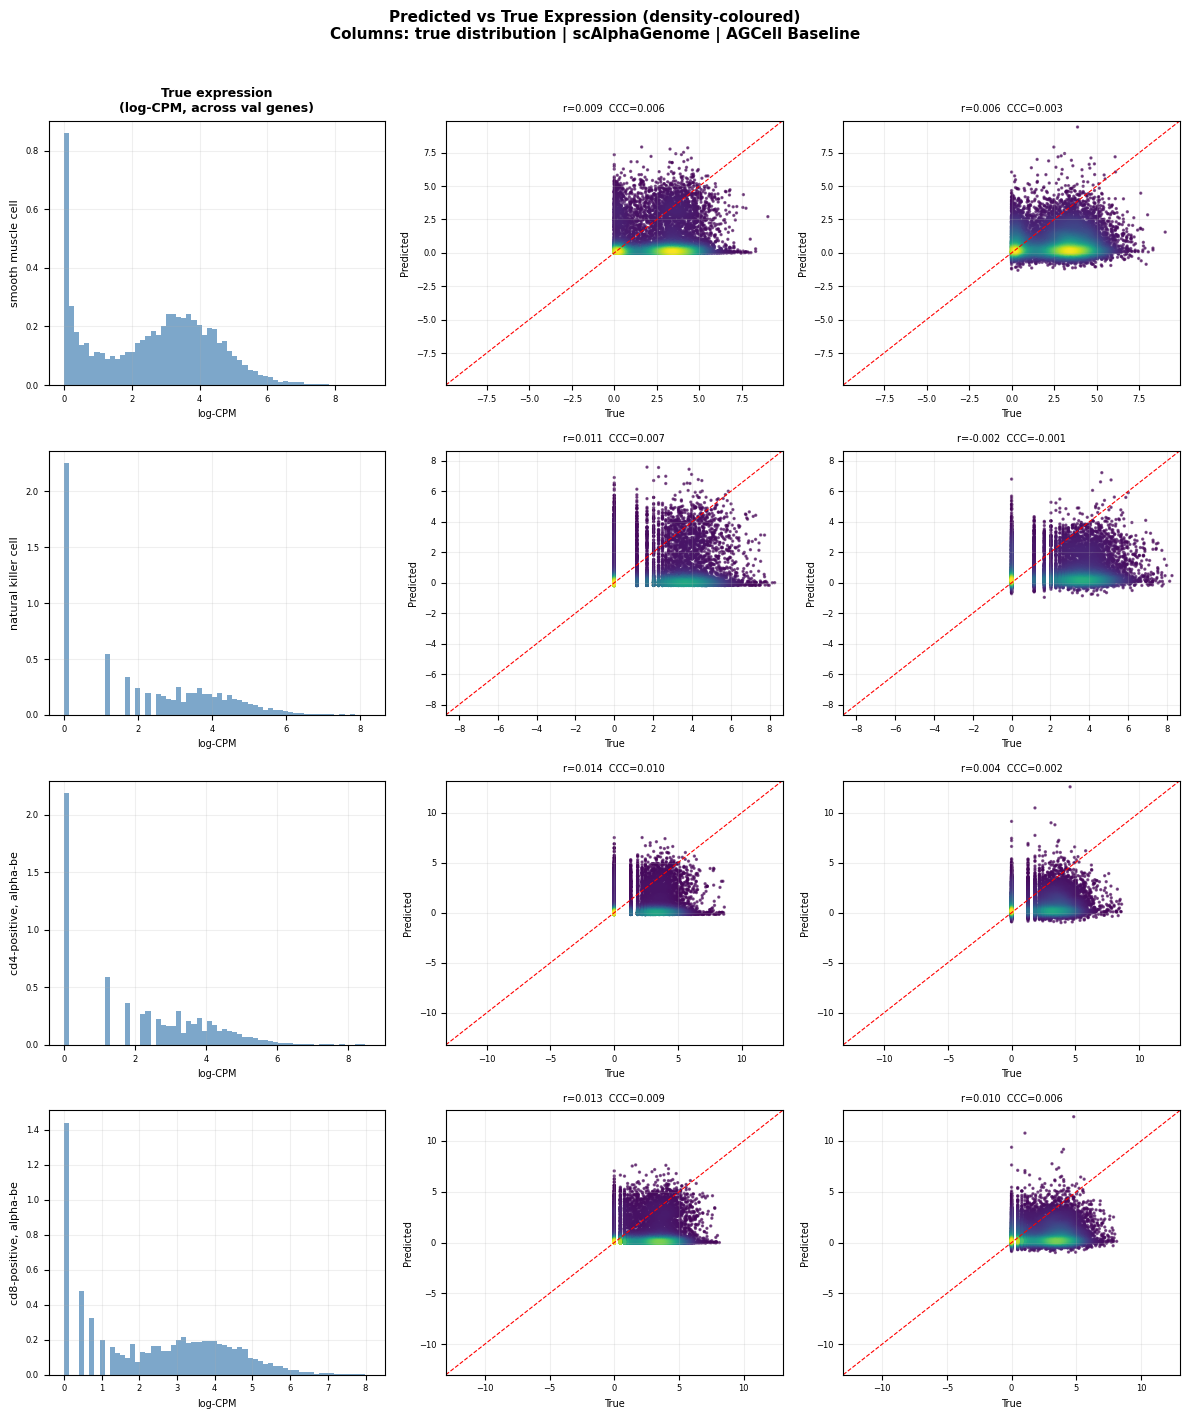

Saved density_scatter_comparison.png


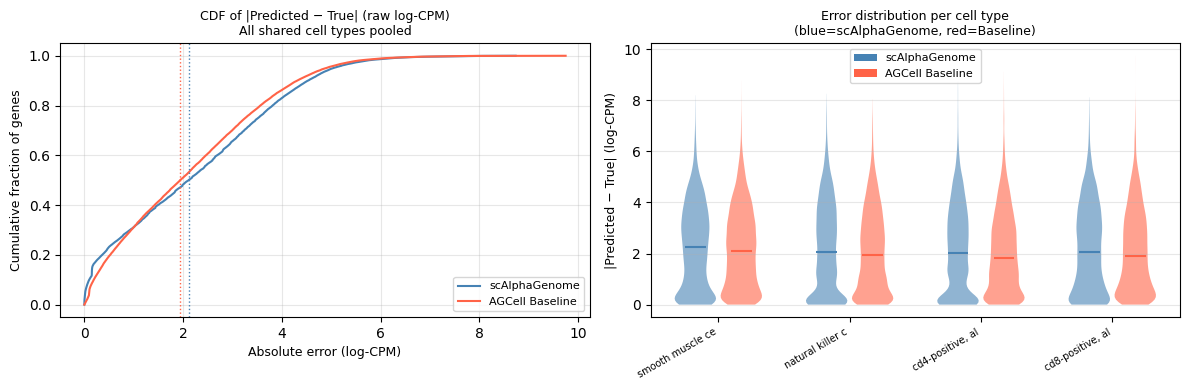

Saved error_distribution.png


In [59]:
# ── Density scatter (main vs baseline) + error CDF ───────────────────────────
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

n_ov  = len(overlap_cts)
ncols = 3   # true vs main vs baseline per row
nrows = n_ov

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows),
                         sharex=False, sharey=False)
if nrows == 1:
    axes = axes[np.newaxis, :]

col_titles = ['True expression\n(log-CPM, across val genes)',
              'scAlphaGenome predicted\nvs True',
              'AGCell Baseline predicted\nvs True']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=9, fontweight='bold')

for i, nm in enumerate(ct_labels):
    t, pm, pb = t_raw[i], p_main[i], p_bl[i]
    lim = max(np.abs(t).max(), np.abs(pm).max(), np.abs(pb).max()) * 1.05

    # Left: histogram of true expression (reference)
    ax0 = axes[i, 0]
    ax0.hist(t, bins=60, color='steelblue', alpha=0.7, density=True)
    ax0.set_ylabel(str(nm)[:22], fontsize=8)
    ax0.set_xlabel('log-CPM', fontsize=7)
    ax0.tick_params(labelsize=6)
    ax0.grid(alpha=0.2)

    for j, (pred, label, color) in enumerate([
        (pm, f'r={pearsonr(t,pm)[0]:.3f}  CCC={concordance_corr(t,pm):.3f}', 'steelblue'),
        (pb, f'r={pearsonr(t,pb)[0]:.3f}  CCC={concordance_corr(t,pb):.3f}', 'tomato'),
    ]):
        ax = axes[i, j + 1]
        # Density-coloured scatter
        try:
            xy  = np.vstack([t, pred])
            kde = gaussian_kde(xy)(xy)
            ord_i = kde.argsort()
            ax.scatter(t[ord_i], pred[ord_i], c=kde[ord_i], s=2,
                       cmap='viridis', alpha=0.6, rasterized=True)
        except Exception:
            ax.scatter(t, pred, s=2, alpha=0.4, color=color, rasterized=True)
        ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.8)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel('True', fontsize=7); ax.set_ylabel('Predicted', fontsize=7)
        ax.set_title(label, fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)

plt.suptitle('Predicted vs True Expression (density-coloured)\n'
             'Columns: true distribution | scAlphaGenome | AGCell Baseline',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('density_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved density_scatter_comparison.png')

# ── Error CDF ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: CDF of |pred - true| (raw log-CPM), pooled across all shared CTs
err_main_all = np.abs(p_main - t_raw).flatten()
err_bl_all   = np.abs(p_bl   - t_raw).flatten()
for ax, errs, labels, title in [
    (axes[0],
     [err_main_all, err_bl_all],
     ['scAlphaGenome', 'AGCell Baseline'],
     'CDF of |Predicted − True| (raw log-CPM)\nAll shared cell types pooled'),
]:
    for err, lbl, col in zip(errs, labels, ['steelblue', 'tomato']):
        sorted_e = np.sort(err)
        cdf      = np.arange(1, len(sorted_e)+1) / len(sorted_e)
        ax.plot(sorted_e, cdf, label=lbl, color=col, linewidth=1.5)
    ax.set_xlabel('Absolute error (log-CPM)', fontsize=9)
    ax.set_ylabel('Cumulative fraction of genes', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # Mark median errors
    for err, col in zip(errs, ['steelblue', 'tomato']):
        med = np.median(err)
        ax.axvline(med, color=col, linestyle=':', linewidth=1)

# Panel B: violin of errors per CT
ax2 = axes[1]
data_main = [np.abs(p_main[i] - t_raw[i]) for i in range(n_ov)]
data_bl   = [np.abs(p_bl[i]   - t_raw[i]) for i in range(n_ov)]
x_pos = np.arange(n_ov)
w = 0.35
vp1 = ax2.violinplot(data_main, positions=x_pos - w/2, widths=w*0.9,
                      showmedians=True, showextrema=False)
vp2 = ax2.violinplot(data_bl,   positions=x_pos + w/2, widths=w*0.9,
                      showmedians=True, showextrema=False)
for pc in vp1['bodies']: pc.set_facecolor('steelblue'); pc.set_alpha(0.6)
for pc in vp2['bodies']: pc.set_facecolor('tomato');    pc.set_alpha(0.6)
vp1['cmedians'].set_color('steelblue'); vp2['cmedians'].set_color('tomato')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(nm)[:16] for nm in ct_labels], rotation=30, ha='right', fontsize=7)
ax2.set_ylabel('|Predicted − True| (log-CPM)', fontsize=9)
ax2.set_title('Error distribution per cell type\n(blue=scAlphaGenome, red=Baseline)', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(handles=[Patch(facecolor='steelblue', label='scAlphaGenome'),
                    Patch(facecolor='tomato',    label='AGCell Baseline')], fontsize=8)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved error_distribution.png')

In [62]:
# ── Coverage advantage: how many MORE cell types does our model support? ───────
# AlphaGenome supports only the CTs in agcell; our model supports ALL CT in scVI data.

print('='*60)
print('COVERAGE ADVANTAGE')
print('='*60)
print(f'Cell types supported by AlphaGenome (agcell heart): {len(agcell_ctids)}')

total_unique_cts = set()
for organ in ORGAN_LIST:
    total_unique_cts.update(organ_data[organ]['cell_type_ids'])

print(f'Cell types supported by scAlphaGenome (all organs):  {len(total_unique_cts)}')
print(f'Coverage multiplier: {len(total_unique_cts) / max(len(agcell_ctids), 1):.1f}x')

novel_cts = total_unique_cts - set(agcell_ctids)
print(f'\nCell types ONLY in scAlphaGenome (no AG support): {len(novel_cts)}')

print('\n' + '='*60)
print('QUALITY ADVANTAGE (AG-supported cell types)')
print('='*60)
if len(overlap_cts) > 0:
    n_main_wins = (comp_main > comp_bl).sum()
    print(f'scAlphaGenome wins: {n_main_wins}/{len(overlap_cts)} cell types')
    print(f'Mean Pearson r — scAlphaGenome: {comp_main.mean():.4f}')
    print(f'Mean Pearson r — AGCell Baseline: {comp_bl.mean():.4f}')
    delta = comp_main.mean() - comp_bl.mean()
    print(f'Δ = {delta:+.4f} ({"scAlphaGenome is better" if delta > 0 else "Baseline is better"})')
else:
    print('No overlapping cell types — coverage advantage only.')

COVERAGE ADVANTAGE
Cell types supported by AlphaGenome (agcell heart): 4
Cell types supported by scAlphaGenome (all organs):  47
Coverage multiplier: 11.8x

Cell types ONLY in scAlphaGenome (no AG support): 43

QUALITY ADVANTAGE (AG-supported cell types)
scAlphaGenome wins: 4/4 cell types
Mean Pearson r — scAlphaGenome: 0.9274
Mean Pearson r — AGCell Baseline: 0.4416
Δ = +0.4858 (scAlphaGenome is better)


In [96]:
# 1. Get predictions from the baseline model for the validation genes
baseline_preds_list = []
baseline_labels_list = []

baseline_model.eval()
with torch.no_grad():
    # assuming you have a loader for the baseline validation set
    for ag_cell_b, label_b in bl_val_loader: 
        preds = baseline_model(ag_cell_b.to(device))
        baseline_preds_list.append(preds.cpu().numpy())
        baseline_labels_list.append(label_b.numpy())

# 2. Concatenate into [N_genes, N_cell_types] matrices
# Note: we transpose to [cell_types, genes] if necessary to match your data loader shape
all_baseline_preds = np.concatenate(baseline_preds_list, axis=0)  # [N_val_genes, N_ct]
all_baseline_labels = np.concatenate(baseline_labels_list, axis=0) # [N_val_genes, N_ct]

# 3. Calculate Pearson r for each gene across cell types
from scipy.stats import pearsonr

n_val_genes = all_baseline_preds.shape[0]
baseline_per_gene_r = np.zeros(n_val_genes)

for i in range(n_val_genes):
    # Calculate correlation between predicted and actual expression across the N cell types
    r, _ = pearsonr(all_baseline_preds[i], all_baseline_labels[i])
    baseline_per_gene_r[i] = r

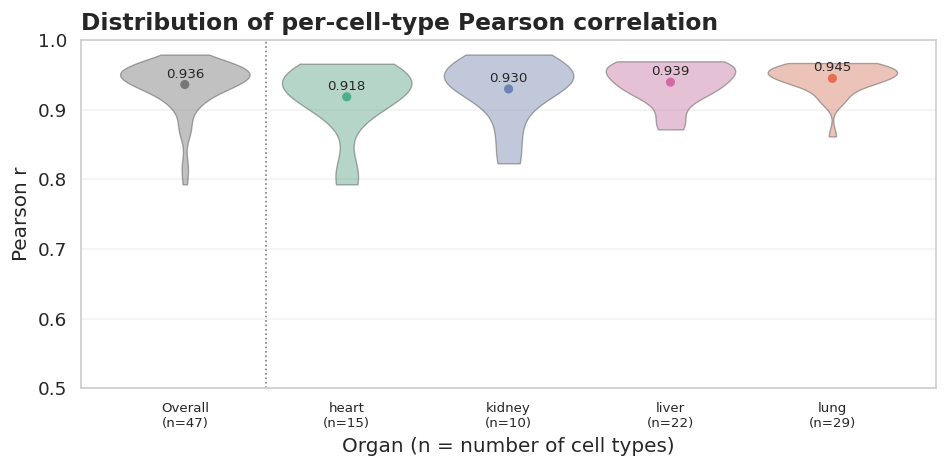

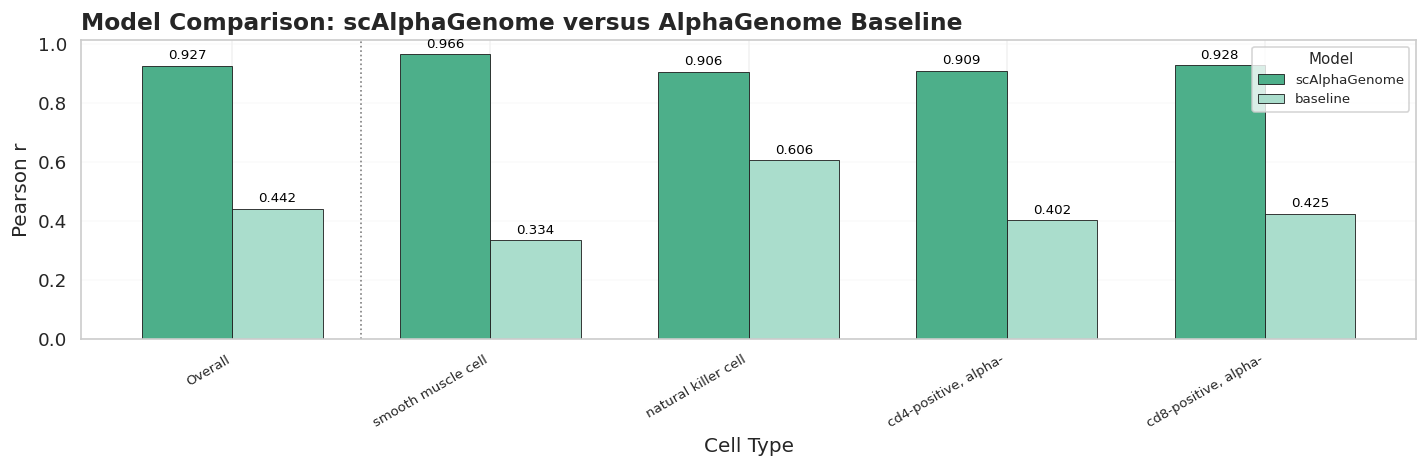

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# STYLE & COLORS (kept)
def set_pub_style():
    sns.set_style("whitegrid", {
        'axes.grid': True,
        'grid.color': '.95',
        'grid.linestyle': '-',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'sans-serif']
    })
    plt.rcParams.update({
        'font.size': 10,
        'axes.linewidth': 1.0,
        'figure.dpi': 120,
        'savefig.transparent': False
    })
    return {'main': '#8CC63F', 'baseline': '#4A4A4A', 'accent': '#669933'}

colors = set_pub_style()
try:
    ORGAN_COLORS = {
        'Overall': '#777777',
        'heart': '#4daf8a',
        'lung' : '#e76f51',
        'kidney': '#6c83b5',
        'liver': '#d46aa5',
    }
    # Only keep organs present in ORGAN_LIST, keep 'Overall'
    ORGAN_COLORS = {k: v for k, v in ORGAN_COLORS.items() if k == 'Overall' or k in ORGAN_LIST}
except Exception:
    ORGAN_COLORS = {'Overall': '#777777', 'heart': '#4daf8a', 'lung': '#e76f51', 'kidney': '#6c83b5', 'liver': '#d46aa5'}

# -----------------------------
# 1) Violin per organ (single axis) with Overall violin to the left and a single small dot (no outline) for mean
# -----------------------------
violin_data = []
for organ, stats in main_pearson.items():
    for val in stats['pearson']:
        violin_data.append({'Organ': organ, 'Pearson r': val})

df_v = pd.DataFrame(violin_data)
organs_sorted = sorted(main_pearson.keys())

# Create pooled "Overall" distribution (all values across organs) and prepend it
overall_df = pd.DataFrame({'Organ': ['Overall'] * len(df_v), 'Pearson r': df_v['Pearson r'].values})
df_v2 = pd.concat([overall_df, df_v], ignore_index=True)

# Order: Overall then individual organs
organs_order = ['Overall'] + organs_sorted

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(x='Organ', y='Pearson r', data=df_v2, order=organs_order,
               palette=[ORGAN_COLORS.get(o, colors['main']) for o in organs_order],
               alpha=0.45, inner=None, linewidth=0.8, ax=ax, cut=0)

# small dot per organ = mean (no outline)
overall_mean = df_v['Pearson r'].mean()
mean_vals = [overall_mean] + [main_pearson[o]['mean_pearson'] for o in organs_sorted]
x_pos = np.arange(len(organs_order))
mean_colors = [ORGAN_COLORS.get(o, colors['main']) for o in organs_order]
ax.scatter(x_pos, mean_vals, color=mean_colors, s=30, edgecolors='none', zorder=10)
for xi, mv in zip(x_pos, mean_vals):
    ax.text(xi, mv + 0.01, f'{mv:.3f}', ha='center', fontsize=8)

# Compute per-organ cell-type counts (and overall unique CT count if possible)
try:
    ct_counts = [len(main_pearson[o]['pearson']) for o in organs_sorted]
    # Prefer the number of unique CT IDs across organs for the Overall count
    overall_cts = set()
    for o in organs_sorted:
        if 'cell_type_ids' in organ_data[o]:
            overall_cts.update(list(organ_data[o]['cell_type_ids']))
    overall_count = len(overall_cts) if len(overall_cts) > 0 else sum(ct_counts)
except Exception:
    ct_counts = [len(main_pearson[o]['pearson']) for o in organs_sorted]
    overall_count = sum(ct_counts)

# Build two-line x-tick labels: name on first line, count on second line
xt_labels = [f'Overall\n(n={overall_count})'] + [f'{o}\n(n={c})' for o, c in zip(organs_sorted, ct_counts)]
ax.set_xticks(x_pos)
ax.set_xticklabels(xt_labels, rotation=0, fontsize=8)

# Add dotted vertical separator between Overall (left) and the organs
ax.axvline(0.5, color='0.5', linestyle=':', linewidth=1)

# Zoom the y-axis to emphasize distribution (start above 0)
ax.set_ylim(0.5, 1.0)
ax.set_title('Distribution of per-cell-type Pearson correlation', loc='left', fontweight='bold')
ax.set_xlabel('Organ (n = number of cell types)')
ax.set_ylabel('Pearson r')
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Head-to-head barplot for heart (Overall moved to the LEFT)
# -----------------------------
if len(overlap_cts) > 0:
    # Original arrays correspond to overlap_cts order.
    main_vals = np.array(comp_main)
    bl_vals   = np.array(comp_bl)
    overall_main = np.nanmean(main_vals)
    overall_bl   = np.nanmean(bl_vals)

    # Prepend Overall so it appears on the left
    main_with_overall = np.concatenate([[overall_main], main_vals])
    bl_with_overall   = np.concatenate([[overall_bl],   bl_vals])
    ct_labels_with_overall = ['Overall'] + list(ct_labels)

    fig, ax = plt.subplots(figsize=(12, 4))
    x_pos = np.arange(len(ct_labels_with_overall))
    w = 0.35
    heart_col = ORGAN_COLORS.get('heart', colors['main'])

    # Bars: shift main left and baseline right per CT, including the Overall group
    b_main = ax.bar(x_pos - w/2, main_with_overall, width=w, label='scAlphaGenome',
                    color=heart_col, edgecolor='k', linewidth=0.5)
    b_bl   = ax.bar(x_pos + w/2, bl_with_overall,   width=w, label='baseline',
                    color='#adc', edgecolor='k', linewidth=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(l)[:20] for l in ct_labels_with_overall], rotation=30, ha='right', fontsize=8)
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('Pearson r')
    ax.set_title('Model Comparison: scAlphaGenome versus AlphaGenome Baseline', loc='left', fontweight='bold')
    ax.legend(title="Model", title_fontsize=9, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.6)

    # Add dotted vertical separator between Overall (left) and the other cell types
    ax.axvline(0.5, color='0.5', linestyle=':', linewidth=1)

    # Annotate bars with numeric Pearson r values (3 decimal places)
    try:
        combined = np.concatenate([np.array(main_with_overall), np.array(bl_with_overall)])
        y_max = np.nanmax(combined)
        y_min = np.nanmin(combined)
        y_range = y_max - y_min if np.isfinite(y_max - y_min) and (y_max - y_min) > 0 else 1.0
    except Exception:
        y_range = 1.0
    offset = y_range * 0.02
    for rect, val in zip(b_main, main_with_overall):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, height + offset, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8, color='black')
    for rect, val in zip(b_bl, bl_with_overall):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, height + offset, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8, color='black')

    plt.tight_layout()
    plt.show()
else:
    print('No overlapping cell types found — skipping head-to-head barplot.')


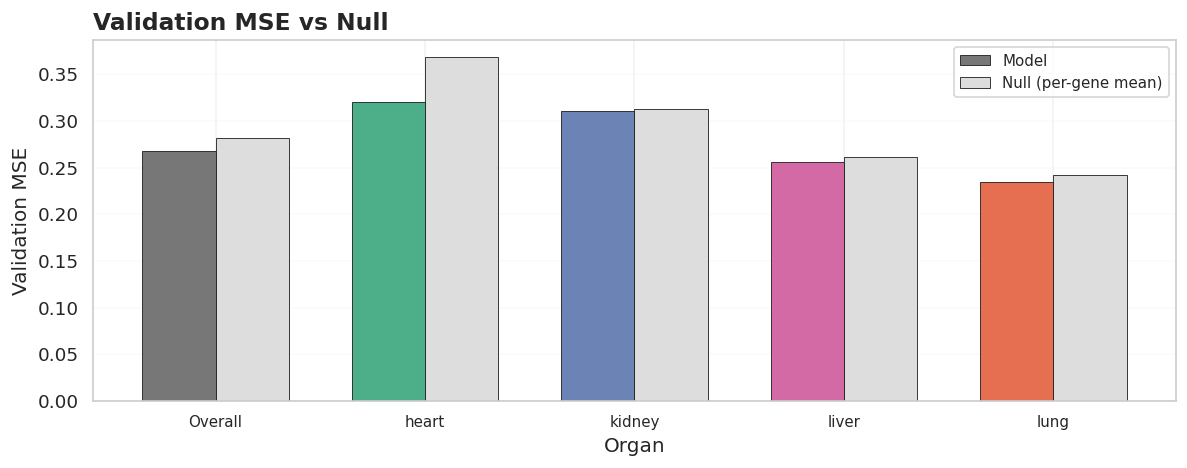

In [162]:
# Validation MSE plot (per-organ + pooled Overall) with Null-model comparison.
# Falls back to epoch val-loss if preds aren't available.
import numpy as np
import matplotlib.pyplot as plt

# Prefer per-organ MSE computed from all_preds / all_true if available
have_preds = ('all_preds' in globals()) and ('all_true' in globals()) and len(all_preds) > 0

if have_preds:
    mse_per_organ = {}
    null_per_organ = {}
    total_sq_model = 0.0
    total_sq_null = 0.0
    total_n = 0

    for organ in sorted(ORGAN_LIST):
        if organ in all_preds and organ in all_true:
            p = np.array(all_preds[organ])
            t = np.array(all_true[organ])

            # Align shapes if needed by flattening to a paired vector
            if p.shape != t.shape:
                p_flat = p.ravel()[:min(p.size, t.size)]
                t_flat = t.ravel()[:min(p.size, t.size)]
                model_mse = np.mean((p_flat - t_flat) ** 2) if p_flat.size > 0 else np.nan
                # For null, compute per-gene mean from the available true vector (flattened)
                gene_mean = np.mean(t_flat)
                null_mse = np.mean((t_flat - gene_mean) ** 2) if t_flat.size > 0 else np.nan
                total_sq_model += np.sum((p_flat - t_flat) ** 2)
                total_sq_null  += np.sum((t_flat - gene_mean) ** 2)
                total_n += p_flat.size
            else:
                # p and t shapes like [n_ct, n_val]
                model_mse = np.mean((p - t) ** 2) if p.size > 0 else np.nan
                # Null predictor: per-gene mean across CTs (axis=0) predicts each CT for that gene
                if t.ndim == 2:
                    gene_mean = t.mean(axis=0, keepdims=True)  # [1, n_val]
                    null_pred = np.repeat(gene_mean, t.shape[0], axis=0)  # [n_ct, n_val]
                    null_mse = np.mean((t - null_pred) ** 2)
                    total_sq_model += np.sum((p - t) ** 2)
                    total_sq_null  += np.sum((t - null_pred) ** 2)
                    total_n += t.size
                else:
                    # fallback to flattened
                    t_flat = t.ravel()
                    model_mse = np.mean((p.ravel() - t_flat) ** 2) if p.size > 0 else np.nan
                    gene_mean = t_flat.mean()
                    null_mse = np.mean((t_flat - gene_mean) ** 2)
                    total_sq_model += np.sum((p.ravel() - t_flat) ** 2)
                    total_sq_null  += np.sum((t_flat - gene_mean) ** 2)
                    total_n += t_flat.size

            mse_per_organ[organ] = model_mse
            null_per_organ[organ] = null_mse
        else:
            print(f"Skipping organ '{organ}': missing preds or true values")

    overall_model_mse = (total_sq_model / total_n) if total_n > 0 else np.nan
    overall_null_mse  = (total_sq_null  / total_n) if total_n > 0 else np.nan

    organs_sorted = sorted(mse_per_organ.keys())
    model_vals = [mse_per_organ[o] for o in organs_sorted]
    null_vals  = [null_per_organ[o] for o in organs_sorted]

    labels = ['Overall'] + organs_sorted
    vals_model = [overall_model_mse] + model_vals
    vals_null  = [overall_null_mse]  + null_vals

    # Colors: model bars use ORGAN_COLORS (Overall included), null bars use a neutral gray
    model_colors = [ORGAN_COLORS.get(l, colors['main']) for l in labels]
    null_color = '#dddddd'
    null_colors = [null_color for _ in labels]

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(labels))
    w = 0.35

    b1 = ax.bar(x - w/2, vals_model, width=w, color=model_colors, edgecolor='k', linewidth=0.5, label='Model')
    b2 = ax.bar(x + w/2, vals_null,  width=w, color=null_colors,  edgecolor='k', linewidth=0.5, label='Null (per-gene mean)')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=9)
    ax.set_ylabel('Validation MSE')
    ax.set_xlabel('Organ')
    ax.set_title('Validation MSE vs Null', loc='left', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()